In [9]:
# from lakeshore import Model240, Model240InputParameter, Model240CurveHeader
import pynanovna
from pynanovna.utils import stream_from_csv
from pynanovna.vis import plot, polar
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import warnings
import time
import datetime
import os
from scipy.optimize import curve_fit
import warnings
import requests
import json
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, plot_errbar, big_plt_font
big_plt_font()
warnings.filterwarnings('once')

vna = pynanovna.VNA()

2026-07-08 11:29:13,190 - root - INFO - Initializing the VNA.
2026-07-08 11:29:17,554 - root - INFO - VNA successfully initialized.


In [10]:
def S21(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (Q/Qc)/(1+2*1j*Q*(f-f0)/f0)

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def S11(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (1 - 2*(Q/Qc)/(1+2*1j*Q*(f-f0)/f0))

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def vec_S21(S21_concat):
    l = int(len(S21_concat)/2)
    r = S21_concat[:l]
    i = S21_concat[l:]
    return [r,i]

def vec_S11(S11_concat):
    l = int(len(S11_concat)/2)
    r = S11_concat[:l]
    i = S11_concat[l:]
    return [r,i]

def mag_S21(re_s21, im_s21):
    return (np.sqrt(re_s21**2+im_s21**2))

def phase_S21(re_s21, im_s21):
    return np.arctan(im_s21/re_s21)

def get_Qi(Q, Qc):
    return 1 / (1/Q - 1/Qc)

def fit_S21(s2p_file, pi = [270e6,500,1000,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])

  freqs_np = np.array(df.freq)
  ReS21 = np.array(df['S21']).astype(complex).real
  ImS21 = np.array(df['S21']).astype(complex).imag

  magS21 = np.sqrt(ReS21**2+ImS21**2)

  

  max_freq = (freqs_np[np.where(magS21==np.max(magS21))])

  start = 250e6  #max_freq[0]-3e6
  stop= 300e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS21_np = np.array(ReS21)[min_index:max_index]
  imS21_np = np.array(ImS21)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S21_data = np.concatenate((reS21_np,imS21_np))

  params, pcov = curve_fit(S21, freqs, S21_data,p0=pi)

  S21_Concat = S21(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  S21_Vec = vec_S21(S21_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S21_mags = np.sqrt(S21_Vec[0]**2+S21_Vec[1]**2)

  plt.plot(freqs/1e6,S21_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S21)')
  plt.legend()

  
  return params

def fit_S11(s2p_file, pi = [227e6,200,100,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  #df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])
  df = pd.read_csv(filepath)

  freqs_np = np.array(df['freq'], dtype=np.float64)
  ReS11 = np.array(df['S11'], dtype=np.complex128).real
  ImS11 = np.array(df['S11'], dtype=np.complex128).imag

  print(np.shape(ReS11))

  magS11 = np.sqrt(ReS11**2+ImS11**2)

  

  max_freq = (freqs_np[np.where(magS11==np.max(magS11))])

  start = 210e6  #max_freq[0]-3e6
  stop= 250e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS11_np = np.array(ReS11)[min_index:max_index]
  imS11_np = np.array(ImS11)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S11_data = np.concatenate((reS11_np,imS11_np))

  params, pcov = curve_fit(S11, freqs, S11_data,p0=pi)

  S11_Concat = S11(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  #S11_Concat = S11(freqs,pi[0],pi[1],pi[2],0,0)#,params[3],params[4])
  S11_Vec = vec_S11(S11_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S11_mags = np.sqrt(S11_Vec[0]**2+S11_Vec[1]**2)

  plt.plot(freqs/1e6,S11_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.plot(freqs/1e6, magS11[min_index:max_index])
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S11)')
  plt.legend()
  return params

In [11]:
#initialize VNA
def vna_sweep(vna, sweep_range,num_points,path,default=101):

    # default = 101

    start = sweep_range[0]
    stop = sweep_range[1]
    point_range = stop-start


    if num_points>default:
        S11 = []
        S21 = []
    
        num_sweeps = int((num_points - num_points%default)/default + 1) #number of sweeps required 
        # print(f'doing {num_sweeps-1} sweeps of {default} points and 1 sweep of  {num_points%default} to achieve {num_points} points')
        sub_sweep = point_range/num_sweeps 

        
        
        S11_sweeps = []
        S21_sweeps = []
        freq_sweeps = []
        
        for i in range(1, num_sweeps):
            freq = np.linspace(start+(i-1)*sub_sweep, start+i*sub_sweep, default)
            # print(min(freq), max(freq), len(freq))
            vna.set_sweep(min(freq), max(freq), len(freq))
            stream = vna.stream()
            data0, data1, freq = vna.sweep()
            
            S11_sweeps.append(data0)
            S21_sweeps.append(data1)
            freq_sweeps.append(freq)

        freq = np.linspace(start+(num_sweeps-1)*sub_sweep, start+num_sweeps*sub_sweep,  num_points%default)
        # print(min(freq), max(freq), len(freq))
        
        vna.set_sweep(min(freq), max(freq), len(freq))
        stream = vna.stream()
        time.sleep(1)
        data0, data1, freq = vna.sweep()
        time.sleep(1)
        S11_sweeps.append(data0)
        S21_sweeps.append(data1)
        freq_sweeps.append(freq)

        S11_data = np.concatenate(S11_sweeps)
        S21_data = np.concatenate(S21_sweeps)
        freq_data = np.concatenate(freq_sweeps)

        data = {'S11': S11_data, 'S21': S21_data, 'freq': freq_data }
        df = pd.DataFrame(data)
        df.to_csv(path, index=False)

    else:
        #vna sweep
        vna.set_sweep(start, stop, num_points)
        stream = vna.stream()
        S11_data, S21_data, freq_data = vna.sweep()

        data = {'S11': S11_data, 'S21': S21_data, 'freq': freq_data }
        df = pd.DataFrame(data)
        df.to_csv(path, index=False)
        #filename = path
        #vna.stream_to_csv(filename, 1)

    return S11_data, S21_data, freq_data

def vna_plot(path, ymin=None, ymax=None):
    # plot VNA data
    df = pd.read_csv(path, skiprows=7, names=["S11", "S21", "freq"])

    S11 = np.array(df["S11"])
    S21 = np.array(df["S21"])
    freq = np.array(df["freq"])

    """
    #find the row that doesnt have data
    bad_index = np.where(S11=='sweepnumber: ')[0][0]
    """
    bad_index = -1
    # get rid of bad row1
    S11_clean = np.array(S11[bad_index + 1 :]).astype(complex)
    S21_clean = np.array(S21[bad_index + 1 :]).astype(complex)
    freq_clean = np.array(freq[bad_index + 1 :])
    S11_mag_db = 20 * np.log10(np.abs(S11_clean))
    S21_mag_db = 20 * np.log10(np.abs(S21_clean))

    plt.plot(freq_clean * 1e-6, S11_mag_db, label="S11")
    # plt.plot(freq_clean * 1e-6, S11_mag_db, alpha=0.2)
    plt.xlabel("frequency (MHz)")
    plt.ylabel("S11 (dB)")
    res = (freq_clean[np.where(S21_mag_db==max(S21_mag_db))])*1e-6
    plt.plot(freq_clean*1e-6,S21_mag_db,label='S21')
    #plt.plot(freq_clean*1e-6,S21_mag_db,alpha=0.2, color='blue')
    plt.xlabel('frequency (MHz)')
    plt.ylabel('S21 (dB)')
    res = (freq_clean[np.where(S21_mag_db == max(S21_mag_db))]) * 1e-6
    plt.title(path)

    # Optional y-axis limits implementation
    if ymin is not None or ymax is not None:
        plt.ylim(bottom=ymin, top=ymax)
    plt.grid(True)
    plt.legend()

In [12]:
def take_vna_sweep(filename, folder_path, f_begin, f_end, vna, N_points=2000): 
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path,filename)
    S11_0, S21_0, freq = vna_sweep(vna, (f_begin, f_end), N_points, file_path)
    return S11_0, S21_0, freq

In [13]:
def query_temp(stage, T_to_channels = {'40K': 1, '4K': 2, '0.4K': 5}): 
    req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
    data = req.json()
    ch = T_to_channels[stage]
    while data['channel_nr'] != ch: 
        req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
        data = req.json()
    return data['temperature']

In [14]:
base = r'/home/electron/data/experiment_07082026/trap_drive'
os.makedirs(base, exist_ok=True)

In [17]:
filename = '4K_trap_drive.csv'
folder_path = base
S11_0, S21_0, freq = take_vna_sweep(filename, folder_path, 1.38e9, 1.68e9, vna, N_points=1400)

2026-07-08 11:36:41,901 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1380000000 step 214285
2026-07-08 11:36:42,290 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-07-08 11:36:42,291 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-07-08 11:36:42,293 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-07-08 11:36:42,295 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1401428571 step 214285
2026-07-08 11:36:42,962 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-07-08 11:36:42,964 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-07-08 11:36:42,965 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-07-08 11:36:42,966 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2

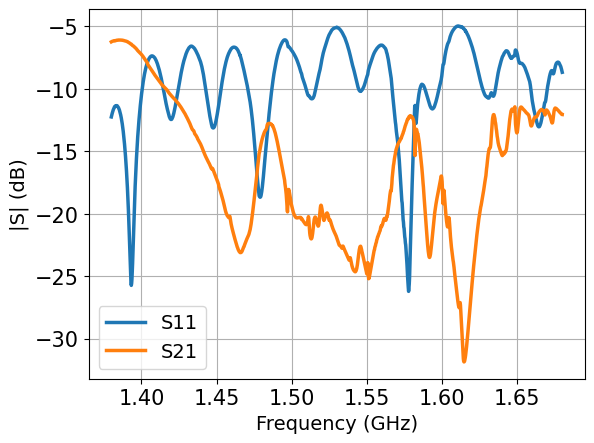

In [18]:
plot(freq/1e9, 20*np.log10(np.abs(S11_0)), label='S11', xlabel='Frequency (GHz)', ylabel='|S| (dB)')
plot(freq/1e9, 20*np.log10(np.abs(S21_0)), label='S21', xlabel='Frequency (GHz)', ylabel='|S| (dB)')
# plt.ylim(-26,-4)
plt.legend() 
plt.show()

In [22]:
freq[np.argmin(20*np.log10(np.abs(S21_0)[:len(S21_0)//2]))]

np.int64(1465714285)

In [11]:
freq[np.argmin(20*np.log10(np.abs(S21_0)))], 20*np.log10(np.abs(S21_0[np.argmin(20*np.log10(np.abs(S21_0)))]))

(np.int64(1472000000), np.float64(-29.700192010897702))

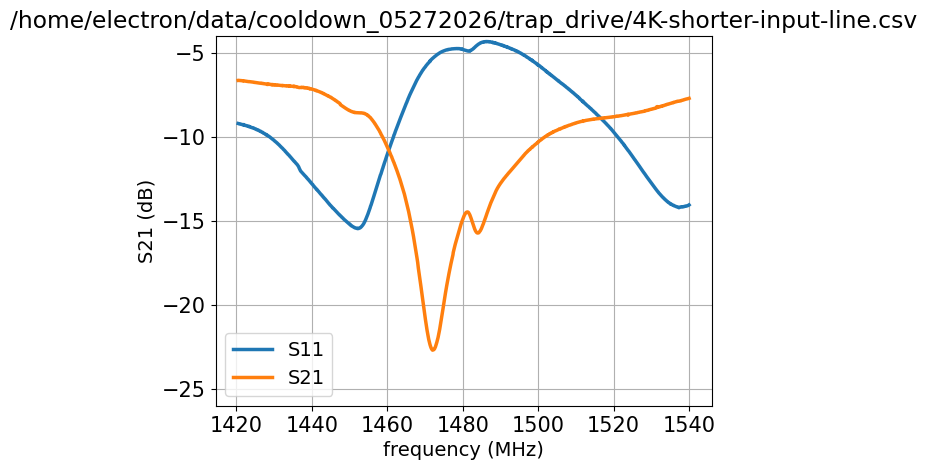

In [32]:
filename = '4K-shorter-input-line.csv'
path = os.path.join(base,filename)
vna_plot(path,ymin=-26,ymax = -4)

2026-05-27 20:02:36,587 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:02:36,973 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:02:36,975 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:02:36,976 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:02:36,978 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:02:37,647 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:02:37,649 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:02:37,650 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:02:37,651 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

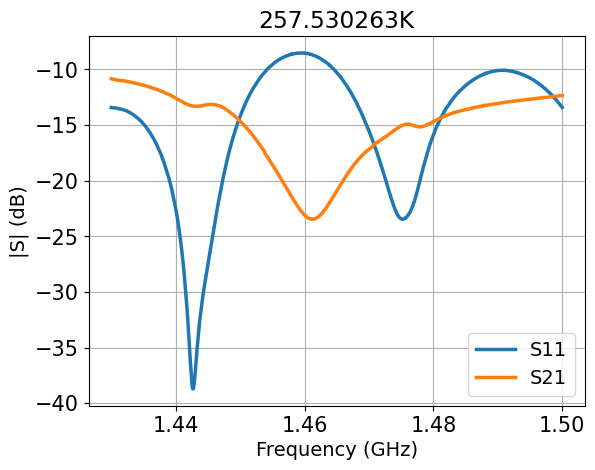

2026-05-27 20:03:00,458 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:03:00,847 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:00,848 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:00,849 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:00,851 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:03:01,520 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:01,521 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:01,522 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:01,524 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

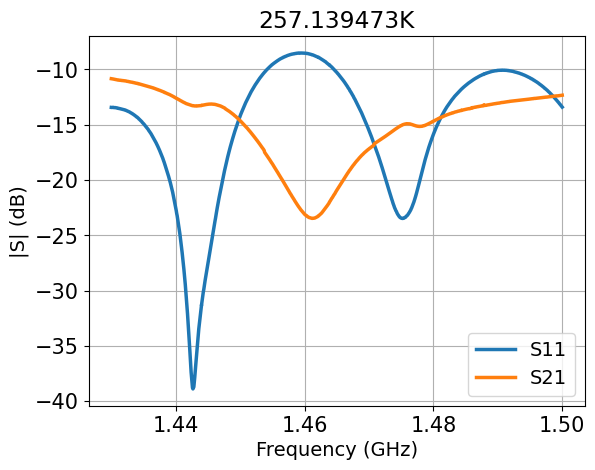

2026-05-27 20:03:08,859 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:03:09,246 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:09,248 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:09,249 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:09,251 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:03:09,920 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:09,922 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:09,923 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:09,924 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

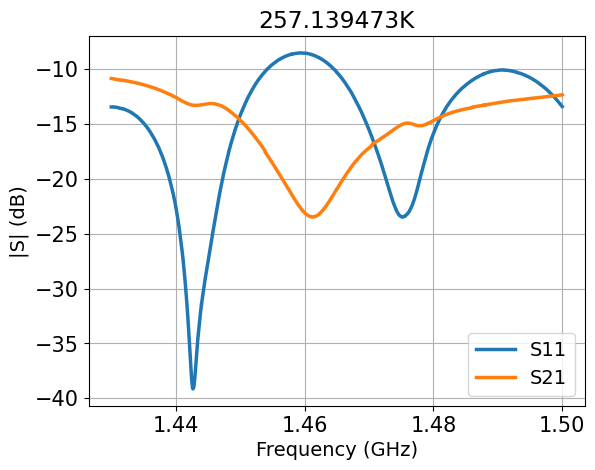

2026-05-27 20:03:34,456 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:03:34,843 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:34,845 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:34,847 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:34,848 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:03:35,516 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:35,517 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:35,519 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:35,521 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

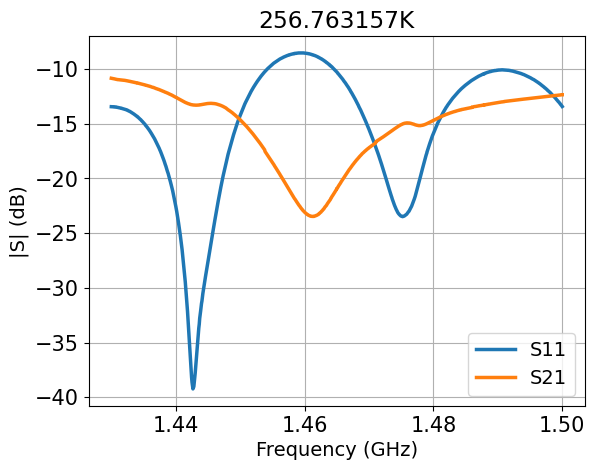

2026-05-27 20:03:42,854 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:03:43,241 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:43,242 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:43,244 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:43,246 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:03:43,915 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:03:43,916 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:43,917 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:03:43,919 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

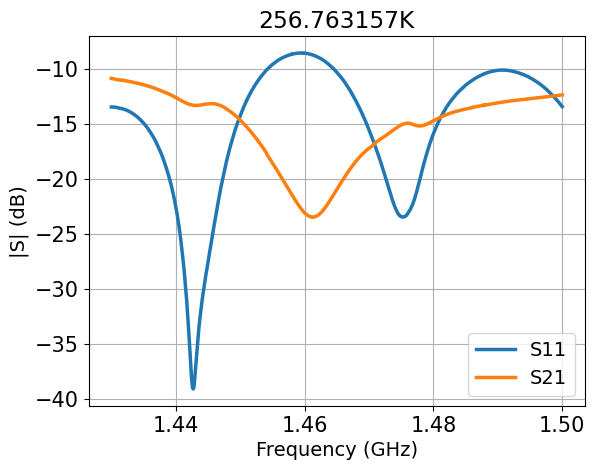

2026-05-27 20:04:08,856 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:04:09,244 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:09,245 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:09,247 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:09,248 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:04:09,917 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:09,918 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:09,919 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:09,919 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

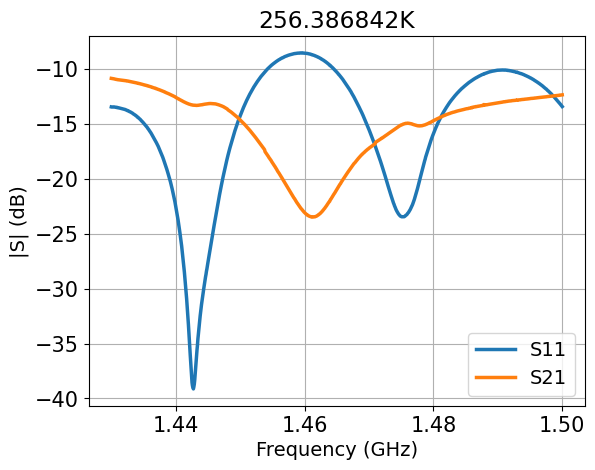

2026-05-27 20:04:17,230 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:04:17,617 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:17,618 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:17,620 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:17,621 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:04:18,290 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:18,292 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:18,293 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:18,295 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

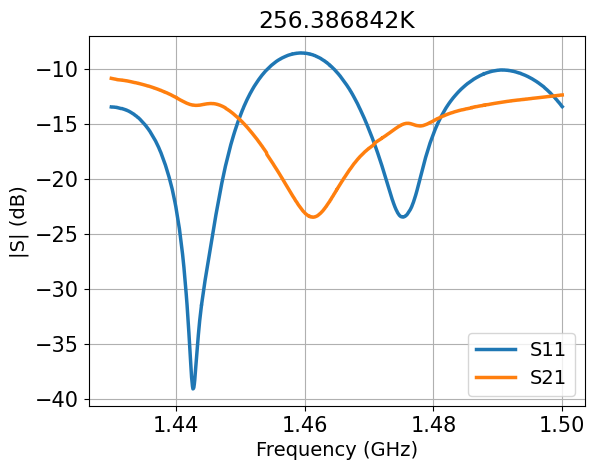

2026-05-27 20:04:43,048 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:04:43,436 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:43,438 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:43,439 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:43,440 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:04:44,107 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:44,109 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:44,110 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:44,112 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

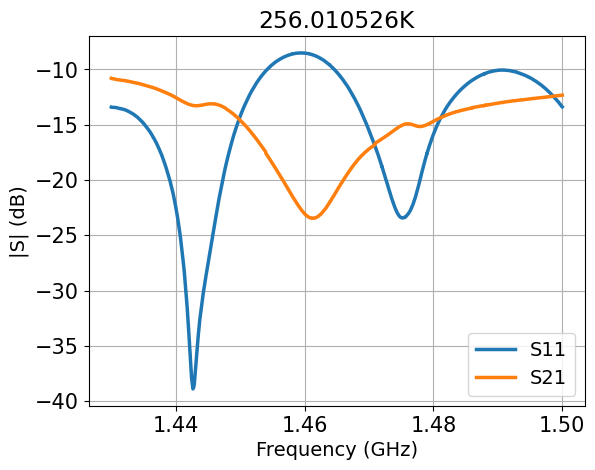

2026-05-27 20:04:51,450 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:04:51,836 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:51,838 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:51,839 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:51,841 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:04:52,509 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:04:52,511 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:52,512 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:04:52,513 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

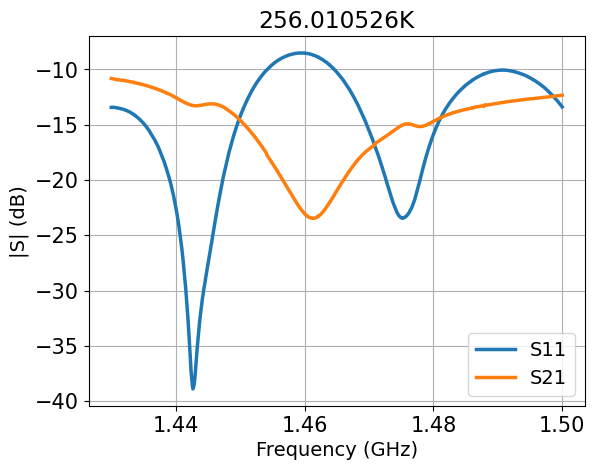

2026-05-27 20:05:17,457 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:05:17,845 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:17,847 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:17,848 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:17,849 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:05:18,517 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:18,518 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:18,520 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:18,522 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

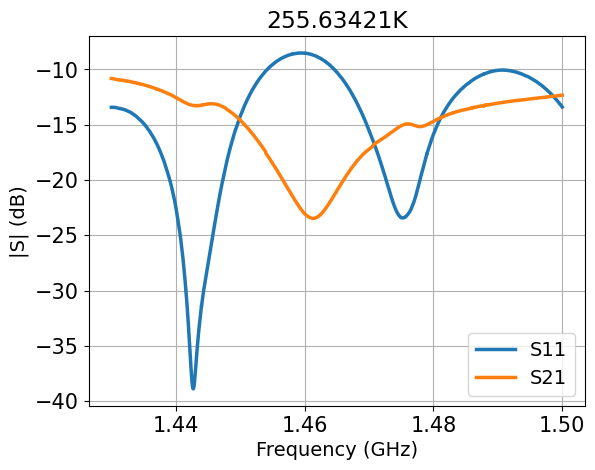

2026-05-27 20:05:25,850 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:05:26,236 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:26,238 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:26,239 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:26,240 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:05:26,907 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:26,908 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:26,908 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:26,908 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

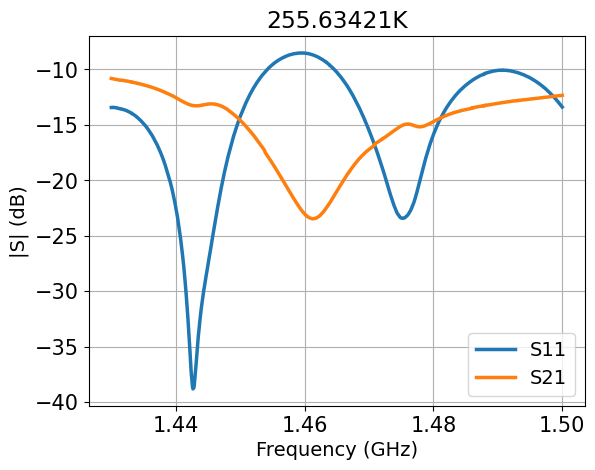

2026-05-27 20:05:51,846 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:05:52,233 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:52,234 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:52,234 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:52,236 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:05:52,904 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:05:52,905 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:52,907 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:05:52,908 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

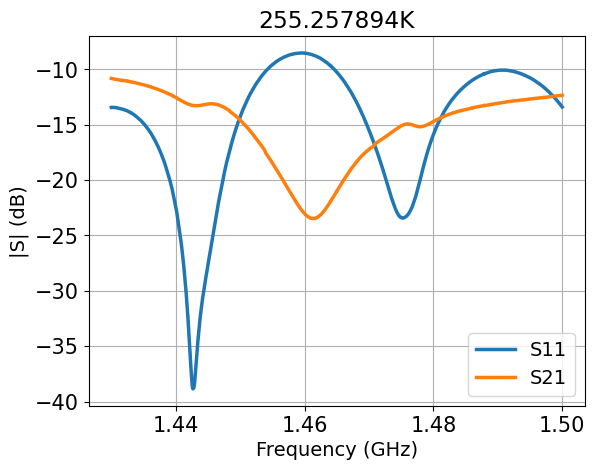

2026-05-27 20:06:00,235 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:06:00,620 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:00,621 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:00,621 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:00,621 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:06:01,288 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:01,290 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:01,291 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:01,292 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

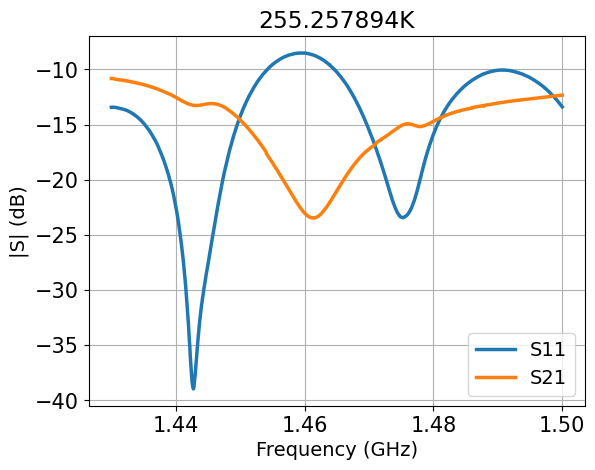

2026-05-27 20:06:26,244 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:06:26,632 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:26,634 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:26,635 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:26,636 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:06:27,302 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:27,303 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:27,304 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:27,304 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

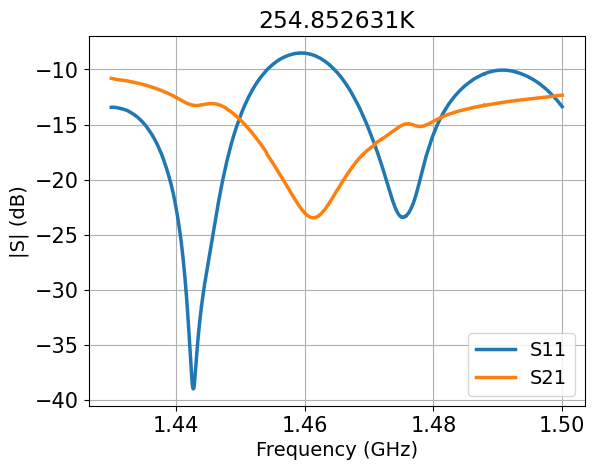

2026-05-27 20:06:34,632 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:06:35,017 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:35,019 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:35,020 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:35,021 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:06:35,688 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:06:35,690 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:35,691 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:06:35,693 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

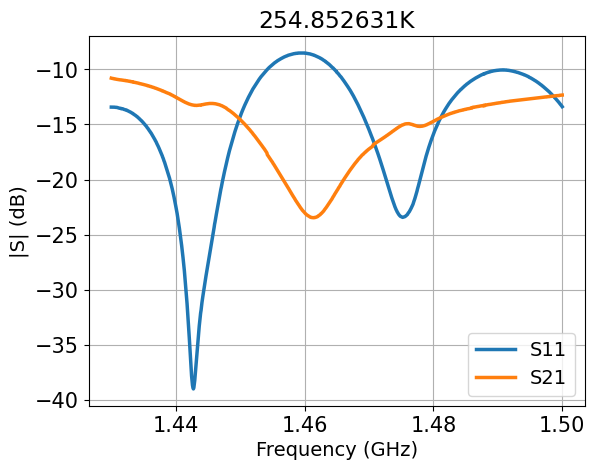

2026-05-27 20:07:00,650 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:07:01,038 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:01,039 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:01,041 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:01,043 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:07:01,711 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:01,713 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:01,714 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:01,716 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

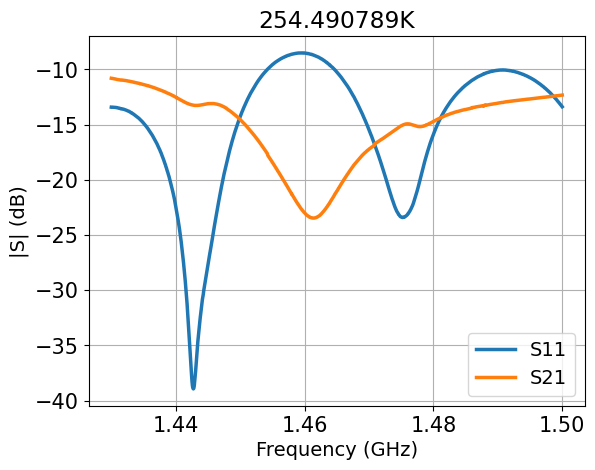

2026-05-27 20:07:09,032 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:07:09,419 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:09,421 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:09,422 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:09,423 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:07:10,091 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:10,093 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:10,094 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:10,096 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

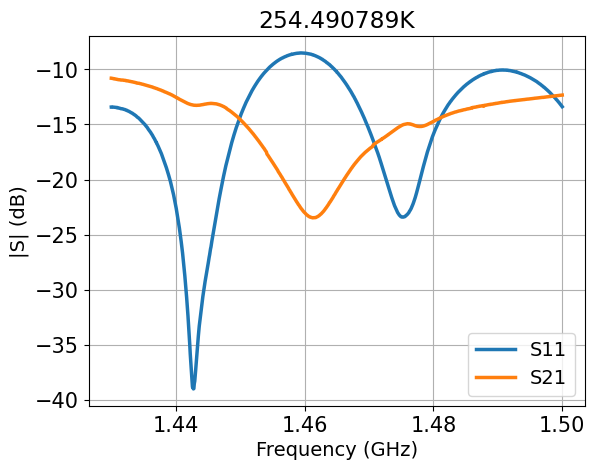

2026-05-27 20:07:34,854 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:07:35,241 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:35,242 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:35,243 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:35,244 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:07:35,911 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:07:35,913 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:35,914 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:07:35,916 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

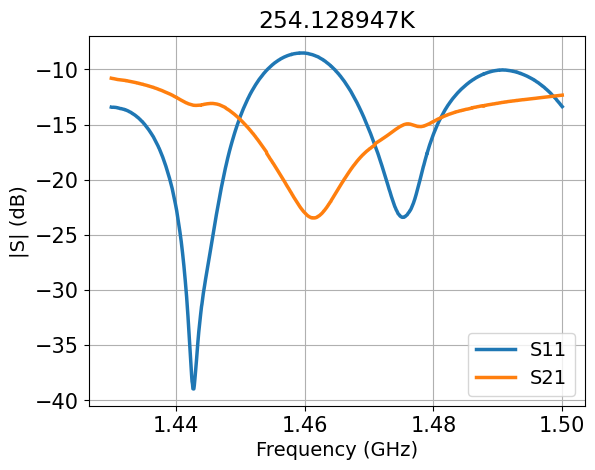

2026-05-27 20:08:09,050 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:08:09,438 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:08:09,439 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:08:09,440 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:08:09,441 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:08:10,110 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:08:10,111 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:08:10,113 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:08:10,115 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

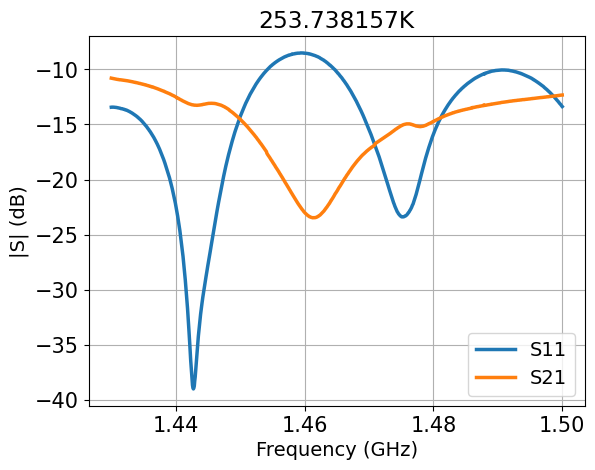

2026-05-27 20:11:01,046 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:11:01,433 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:11:01,434 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:11:01,434 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:11:01,435 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:11:02,102 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:11:02,104 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:11:02,105 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:11:02,106 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

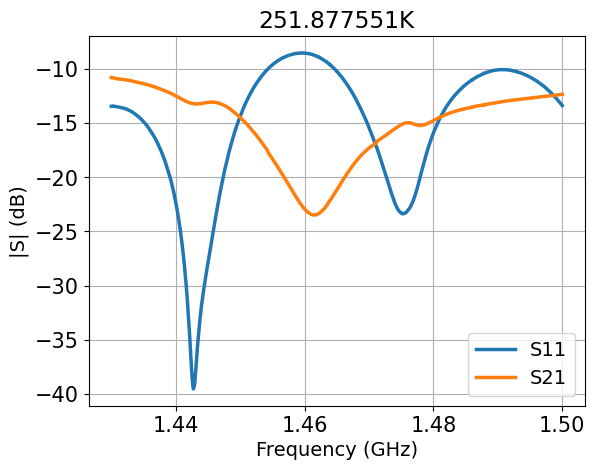

2026-05-27 20:14:26,838 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:14:27,226 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:14:27,227 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:14:27,228 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:14:27,230 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:14:27,898 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:14:27,899 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:14:27,901 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:14:27,903 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

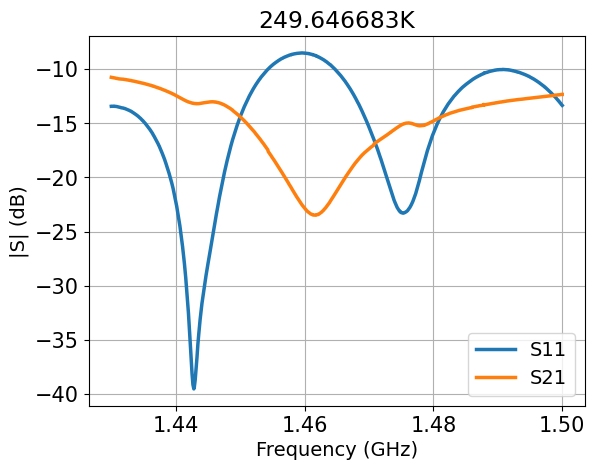

2026-05-27 20:17:18,846 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:17:19,233 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:17:19,234 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:17:19,236 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:17:19,237 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:17:19,905 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:17:19,906 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:17:19,908 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:17:19,909 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

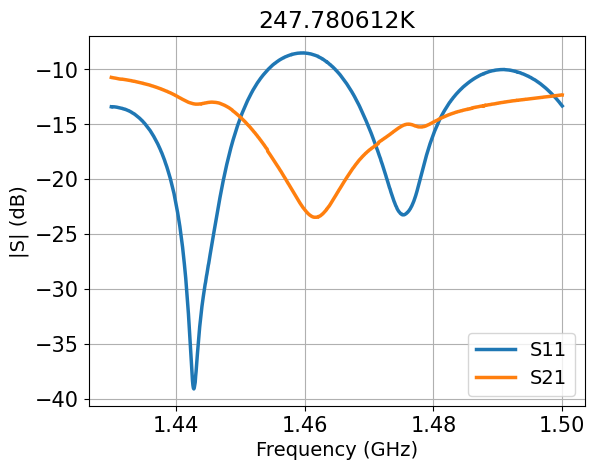

2026-05-27 20:20:45,247 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:20:45,635 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:20:45,636 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:20:45,637 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:20:45,639 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:20:46,307 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:20:46,308 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:20:46,309 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:20:46,311 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

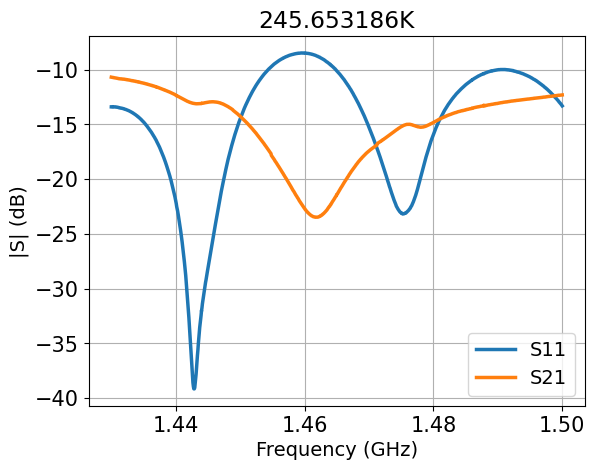

2026-05-27 20:23:37,044 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:23:37,432 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:23:37,433 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:23:37,434 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:23:37,436 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:23:38,104 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:23:38,106 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:23:38,107 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:23:38,108 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

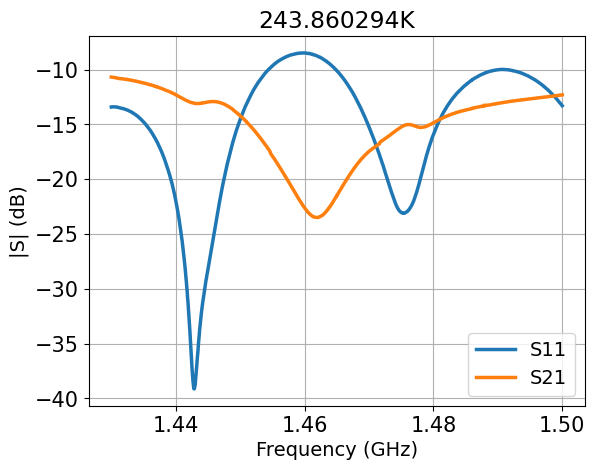

2026-05-27 20:27:03,027 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:27:03,415 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:27:03,416 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:27:03,418 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:27:03,419 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:27:04,087 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:27:04,089 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:27:04,090 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:27:04,091 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

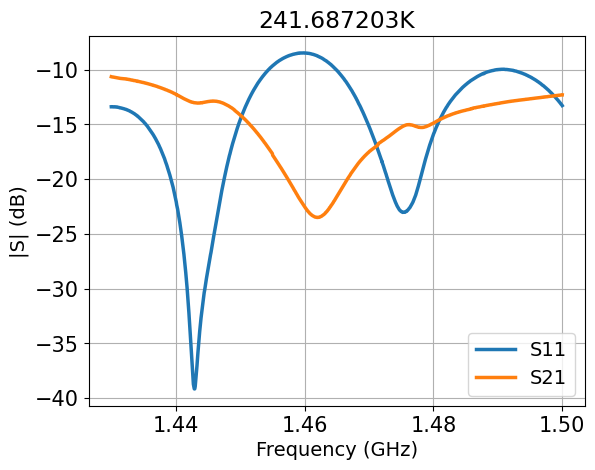

2026-05-27 20:29:54,829 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:29:55,217 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:29:55,218 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:29:55,220 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:29:55,221 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:29:55,889 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:29:55,890 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:29:55,892 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:29:55,894 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

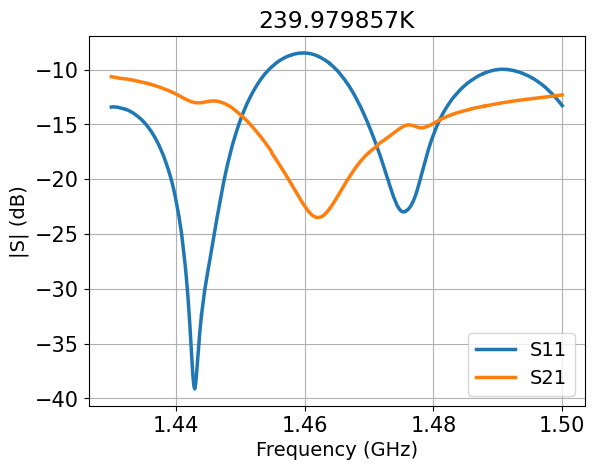

2026-05-27 20:33:21,226 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:33:21,614 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:33:21,616 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:33:21,617 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:33:21,618 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:33:22,286 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:33:22,287 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:33:22,288 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:33:22,289 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

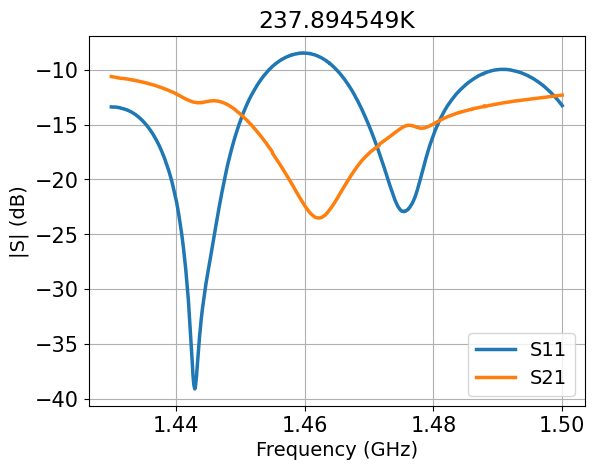

2026-05-27 20:36:47,226 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:36:47,613 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:36:47,615 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:36:47,616 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:36:47,617 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:36:48,286 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:36:48,287 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:36:48,288 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:36:48,290 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

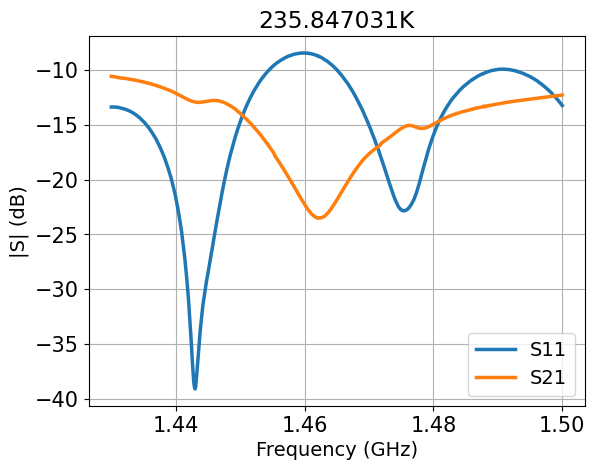

2026-05-27 20:40:13,424 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:40:13,811 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:40:13,813 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:40:13,814 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:40:13,815 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:40:14,483 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:40:14,485 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:40:14,486 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:40:14,488 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

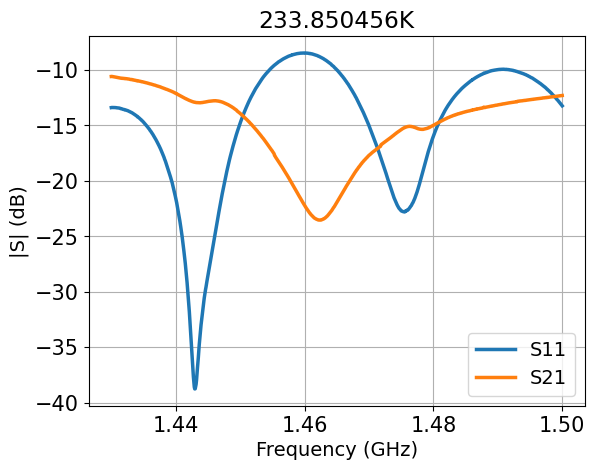

2026-05-27 20:43:39,403 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:43:39,791 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:43:39,792 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:43:39,793 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:43:39,794 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:43:40,462 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:43:40,464 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:43:40,465 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:43:40,467 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

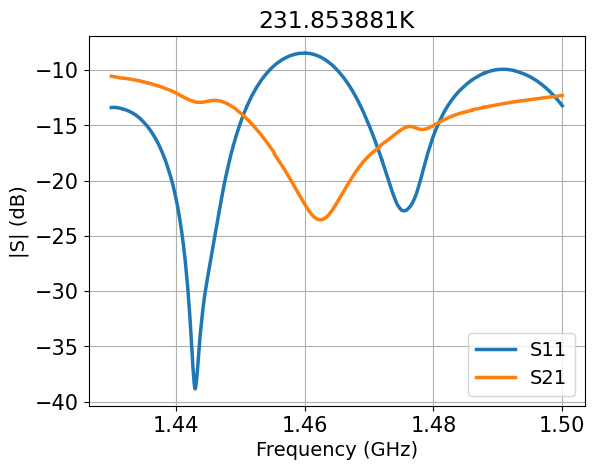

2026-05-27 20:47:05,220 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:47:05,608 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:47:05,610 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:47:05,611 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:47:05,613 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:47:06,280 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:47:06,282 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:47:06,283 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:47:06,285 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

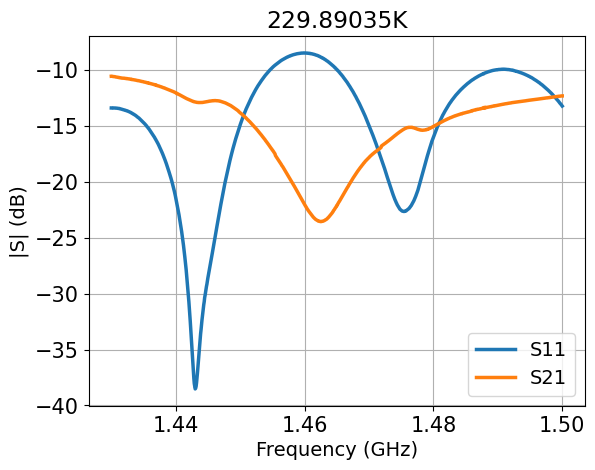

2026-05-27 20:50:31,199 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:50:31,587 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:50:31,588 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:50:31,589 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:50:31,590 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:50:32,259 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:50:32,260 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:50:32,262 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:50:32,263 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

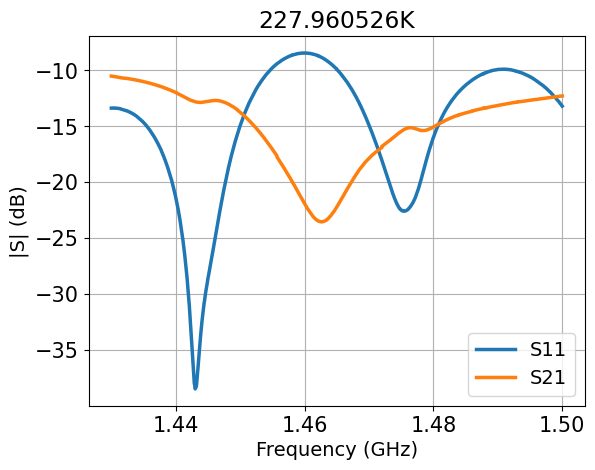

2026-05-27 20:54:31,803 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:54:32,191 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:54:32,192 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:54:32,194 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:54:32,197 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:54:32,865 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:54:32,867 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:54:32,868 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:54:32,870 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

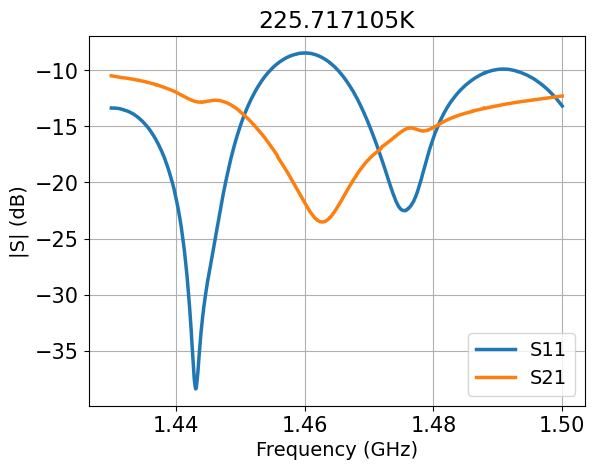

2026-05-27 20:57:58,003 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 20:57:58,390 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:57:58,391 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:57:58,392 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:57:58,393 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 20:57:59,061 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 20:57:59,062 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:57:59,064 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 20:57:59,066 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

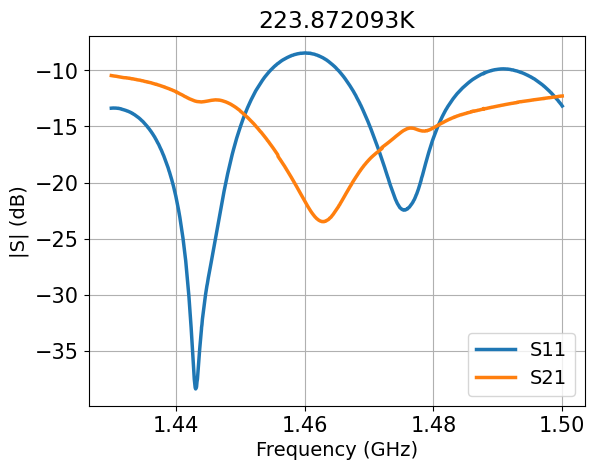

2026-05-27 21:01:58,584 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:01:58,972 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:01:58,974 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:01:58,975 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:01:58,976 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:01:59,643 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:01:59,645 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:01:59,646 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:01:59,648 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

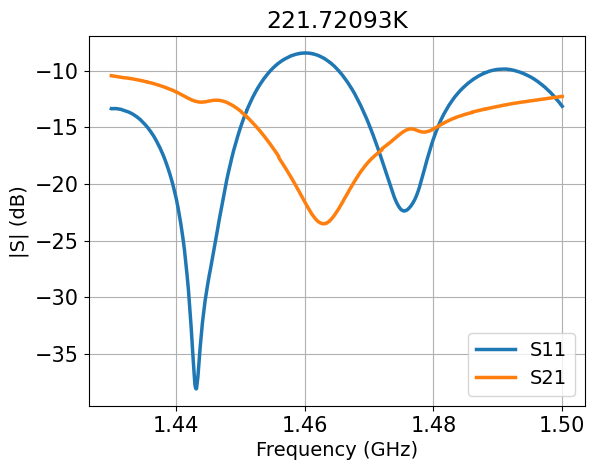

2026-05-27 21:05:24,588 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:05:24,976 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:05:24,977 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:05:24,979 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:05:24,980 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:05:25,648 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:05:25,649 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:05:25,651 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:05:25,652 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

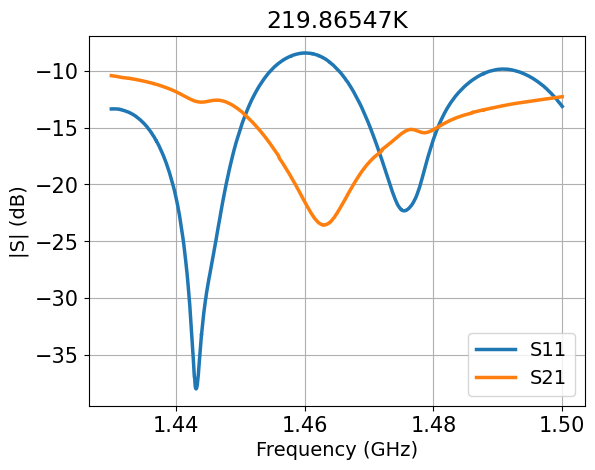

2026-05-27 21:09:25,176 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:09:25,564 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:09:25,565 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:09:25,566 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:09:25,568 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:09:26,236 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:09:26,237 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:09:26,238 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:09:26,240 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

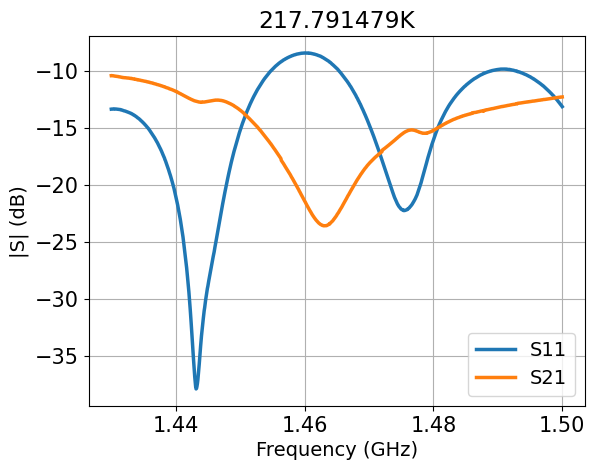

2026-05-27 21:13:26,185 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:13:26,572 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:13:26,574 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:13:26,575 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:13:26,577 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:13:27,244 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:13:27,246 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:13:27,247 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:13:27,249 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

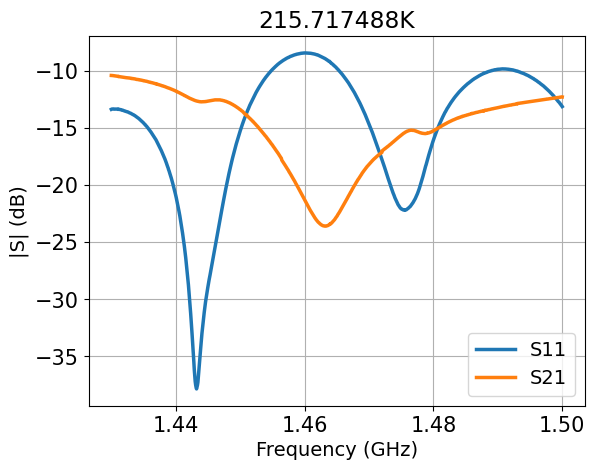

2026-05-27 21:16:52,181 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:16:52,569 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:16:52,570 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:16:52,572 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:16:52,573 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:16:53,241 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:16:53,242 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:16:53,244 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:16:53,246 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

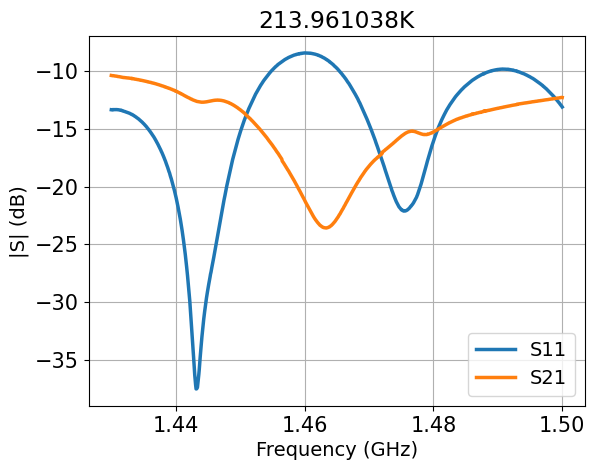

2026-05-27 21:20:52,762 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:20:53,150 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:20:53,151 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:20:53,153 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:20:53,154 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:20:53,822 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:20:53,824 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:20:53,825 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:20:53,827 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

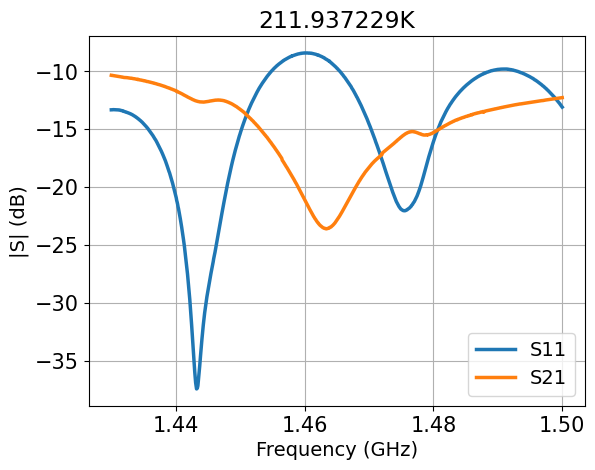

2026-05-27 21:24:53,161 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:24:53,549 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:24:53,551 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:24:53,552 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:24:53,553 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:24:54,221 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:24:54,223 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:24:54,224 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:24:54,226 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

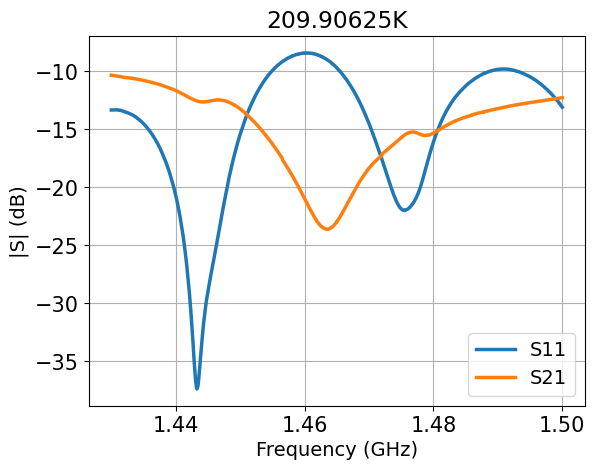

2026-05-27 21:29:05,158 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:29:05,546 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:29:05,547 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:29:05,549 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:29:05,551 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:29:06,219 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:29:06,220 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:29:06,222 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:29:06,224 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

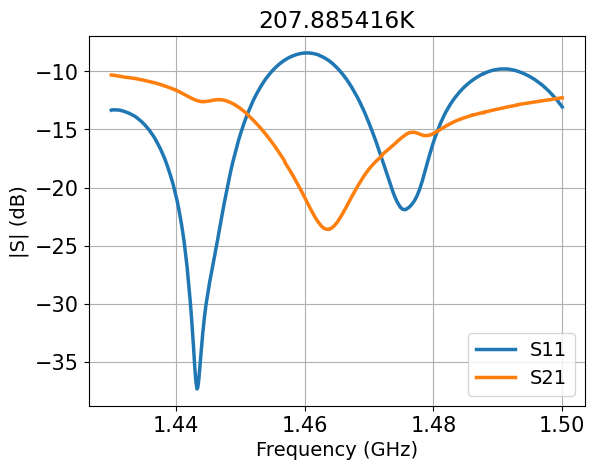

2026-05-27 21:33:05,560 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:33:05,948 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:33:05,949 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:33:05,951 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:33:05,953 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:33:06,621 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:33:06,623 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:33:06,625 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:33:06,626 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

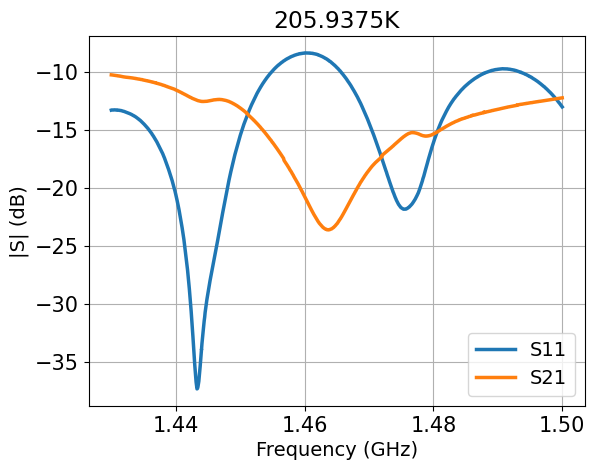

2026-05-27 21:37:40,361 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:37:40,749 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:37:40,750 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:37:40,752 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:37:40,753 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:37:41,420 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:37:41,421 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:37:41,422 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:37:41,422 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

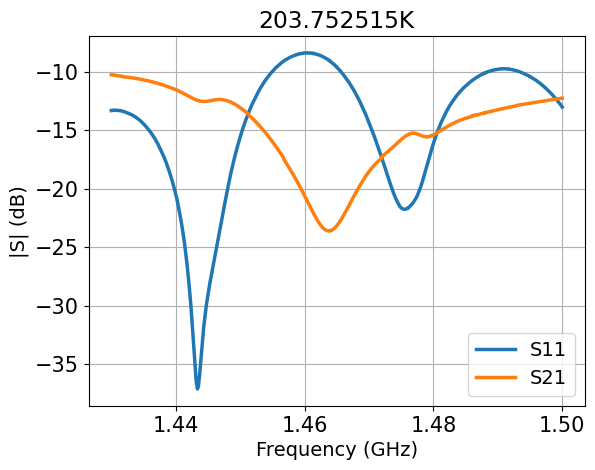

2026-05-27 21:41:41,157 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:41:41,545 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:41:41,547 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:41:41,548 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:41:41,550 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:41:42,219 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:41:42,221 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:41:42,224 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:41:42,225 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

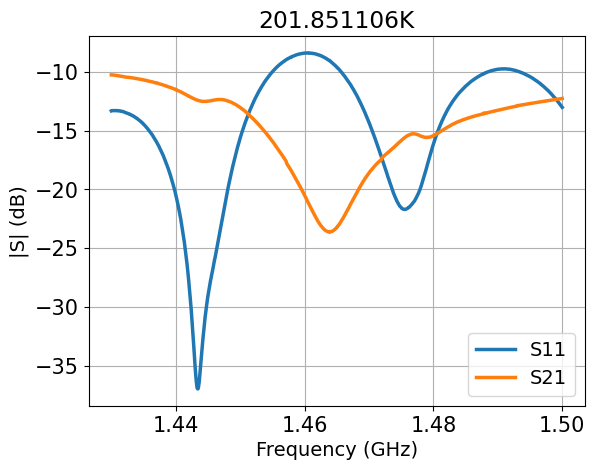

2026-05-27 21:45:41,749 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:45:42,136 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:45:42,137 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:45:42,139 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:45:42,141 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:45:42,809 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:45:42,810 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:45:42,811 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:45:42,813 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

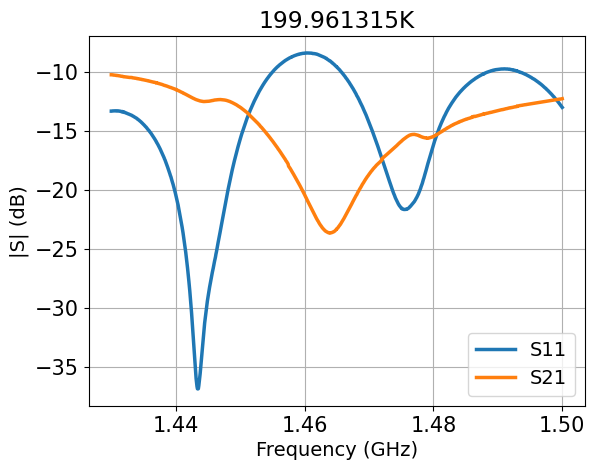

2026-05-27 21:50:16,545 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:50:16,932 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:50:16,934 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:50:16,935 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:50:16,936 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:50:17,603 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:50:17,605 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:50:17,605 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:50:17,606 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

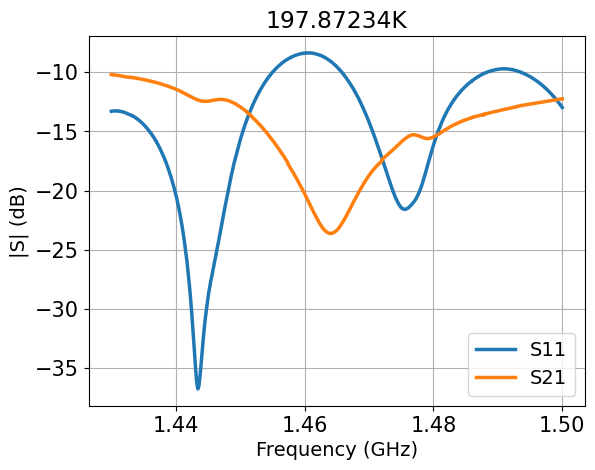

2026-05-27 21:54:51,358 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:54:51,746 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:54:51,748 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:54:51,749 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:54:51,750 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:54:52,418 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:54:52,420 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:54:52,421 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:54:52,422 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

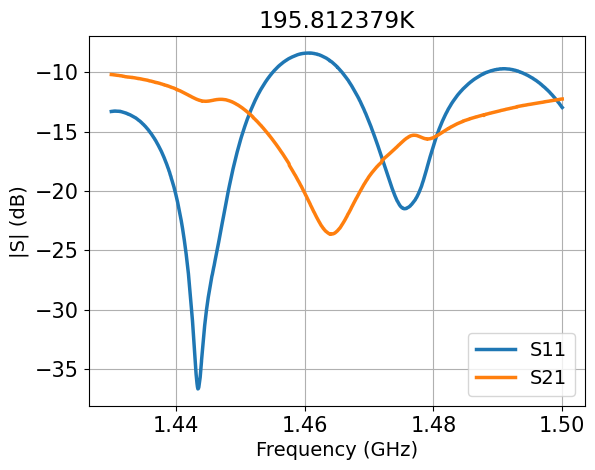

2026-05-27 21:58:51,733 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 21:58:52,120 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:58:52,122 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:58:52,123 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:58:52,124 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 21:58:52,794 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 21:58:52,795 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:58:52,797 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 21:58:52,798 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

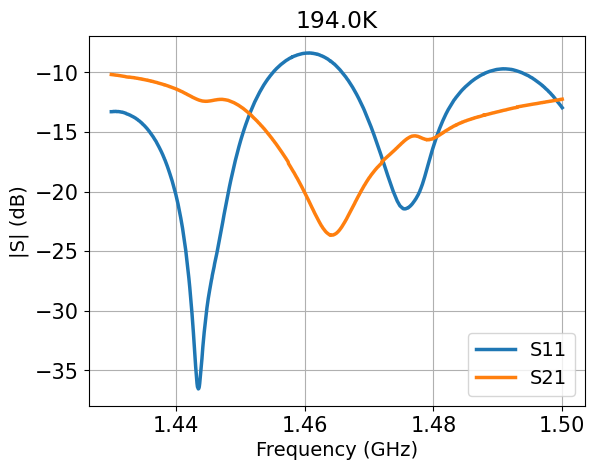

2026-05-27 22:03:26,746 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:03:27,133 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:03:27,135 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:03:27,136 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:03:27,138 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:03:27,806 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:03:27,807 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:03:27,809 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:03:27,811 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

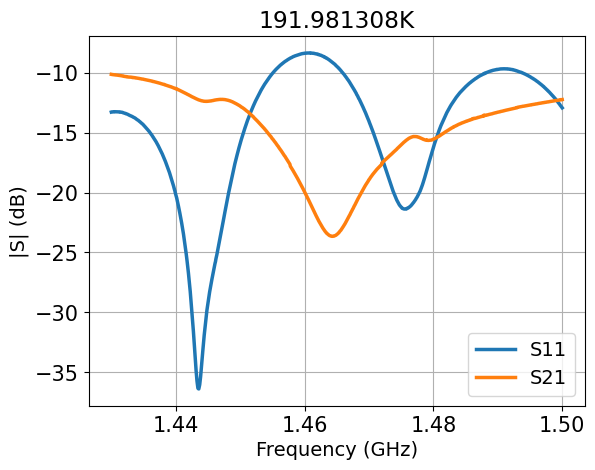

2026-05-27 22:08:01,535 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:08:01,922 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:08:01,924 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:08:01,925 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:08:01,927 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:08:02,595 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:08:02,596 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:08:02,597 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:08:02,599 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

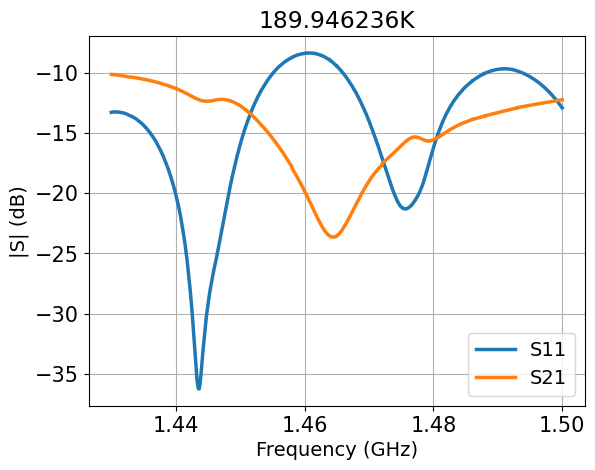

2026-05-27 22:13:10,726 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:13:11,114 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:13:11,115 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:13:11,116 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:13:11,117 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:13:11,785 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:13:11,787 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:13:11,788 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:13:11,790 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

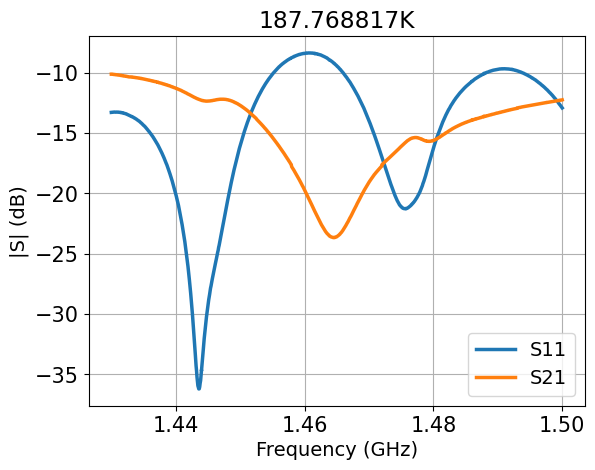

2026-05-27 22:17:45,517 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:17:45,905 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:17:45,906 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:17:45,907 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:17:45,909 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:17:46,577 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:17:46,578 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:17:46,580 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:17:46,582 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

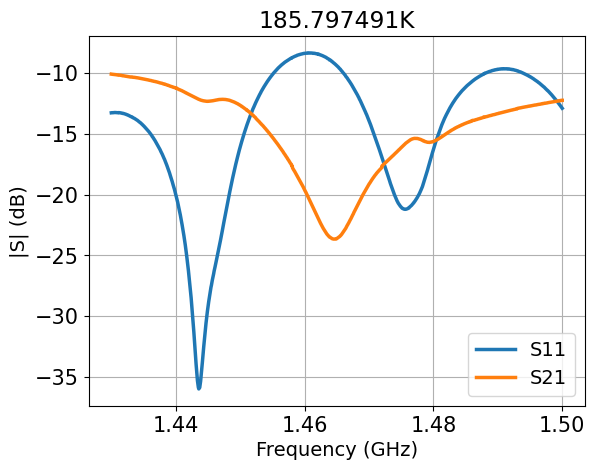

2026-05-27 22:22:20,514 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:22:20,902 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:22:20,903 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:22:20,904 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:22:20,905 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:22:21,574 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:22:21,575 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:22:21,576 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:22:21,577 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

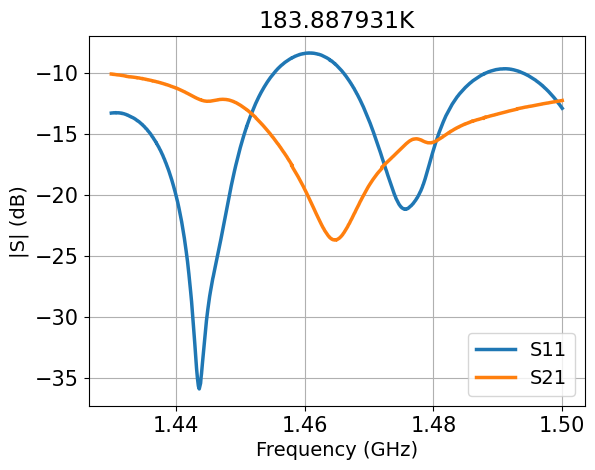

2026-05-27 22:26:55,496 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:26:55,884 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:26:55,885 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:26:55,887 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:26:55,888 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:26:56,556 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:26:56,557 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:26:56,559 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:26:56,560 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

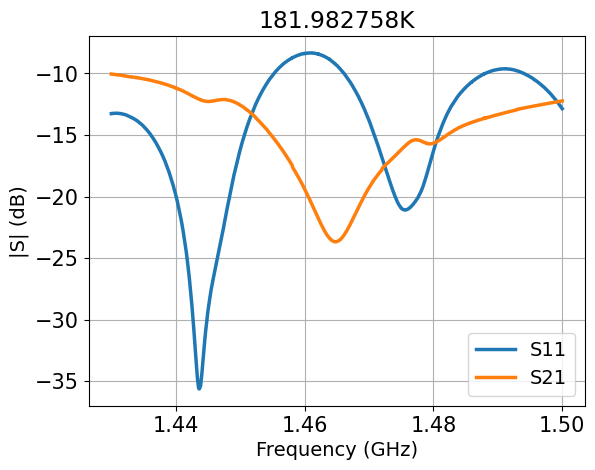

2026-05-27 22:32:04,703 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:32:05,090 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:32:05,091 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:32:05,092 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:32:05,092 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:32:05,759 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:32:05,761 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:32:05,763 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:32:05,764 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

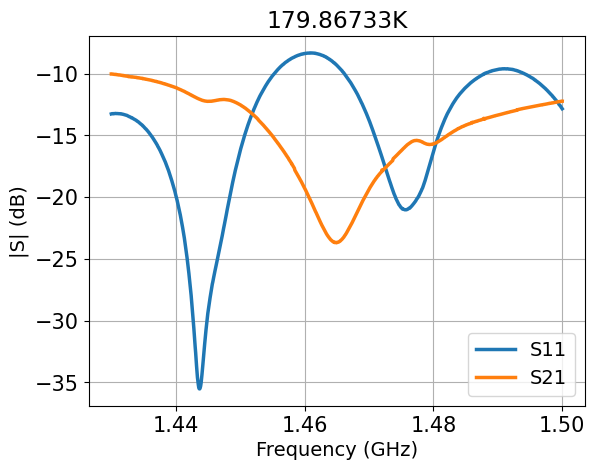

2026-05-27 22:37:13,694 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:37:14,082 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:37:14,083 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:37:14,085 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:37:14,086 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:37:14,754 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:37:14,755 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:37:14,757 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:37:14,759 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

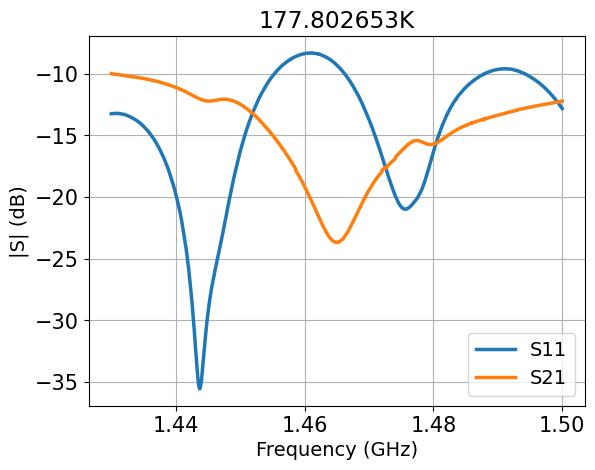

2026-05-27 22:41:48,484 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:41:48,872 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:41:48,873 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:41:48,875 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:41:48,876 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:41:49,544 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:41:49,545 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:41:49,547 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:41:49,548 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

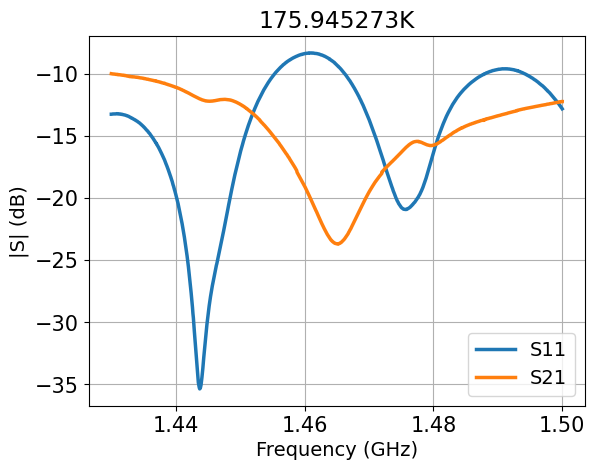

2026-05-27 22:46:57,680 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:46:58,068 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:46:58,070 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:46:58,071 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:46:58,072 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:46:58,740 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:46:58,742 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:46:58,743 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:46:58,745 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

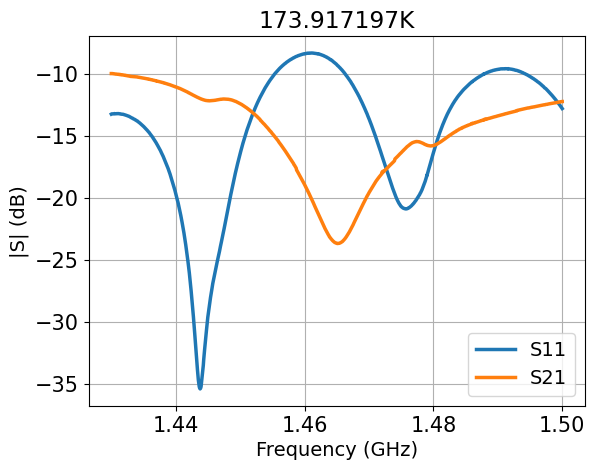

2026-05-27 22:52:06,696 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:52:07,084 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:52:07,085 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:52:07,087 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:52:07,089 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:52:07,757 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:52:07,759 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:52:07,760 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:52:07,762 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

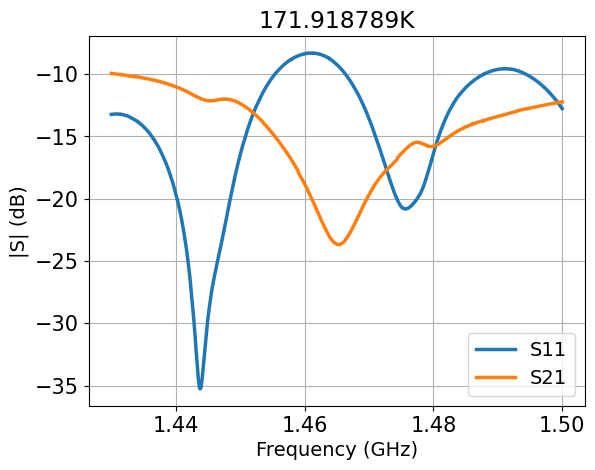

2026-05-27 22:57:15,885 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 22:57:16,273 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:57:16,274 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:57:16,275 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:57:16,277 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 22:57:16,945 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 22:57:16,946 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:57:16,948 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 22:57:16,950 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

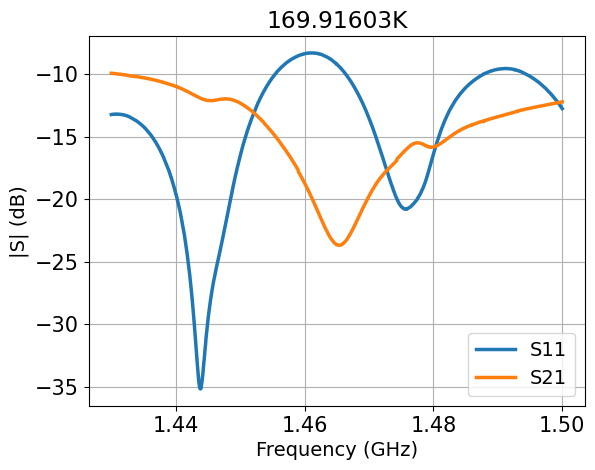

2026-05-27 23:02:25,060 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:02:25,448 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:02:25,450 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:02:25,452 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:02:25,453 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:02:26,121 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:02:26,123 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:02:26,124 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:02:26,126 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

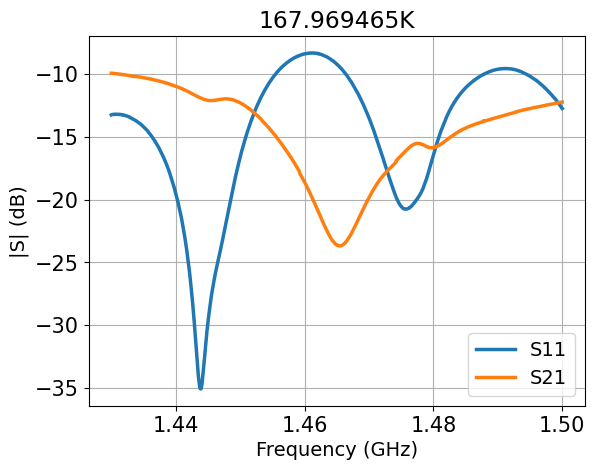

2026-05-27 23:08:08,850 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:08:09,238 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:08:09,239 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:08:09,241 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:08:09,242 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:08:09,911 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:08:09,912 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:08:09,913 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:08:09,915 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

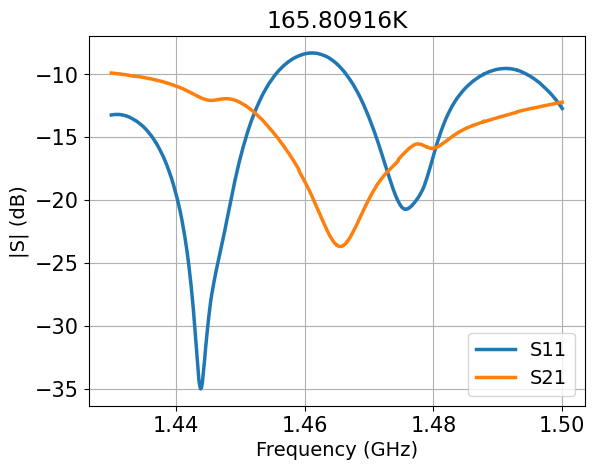

2026-05-27 23:13:17,854 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:13:18,243 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:13:18,244 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:13:18,245 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:13:18,247 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:13:18,916 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:13:18,917 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:13:18,919 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:13:18,920 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

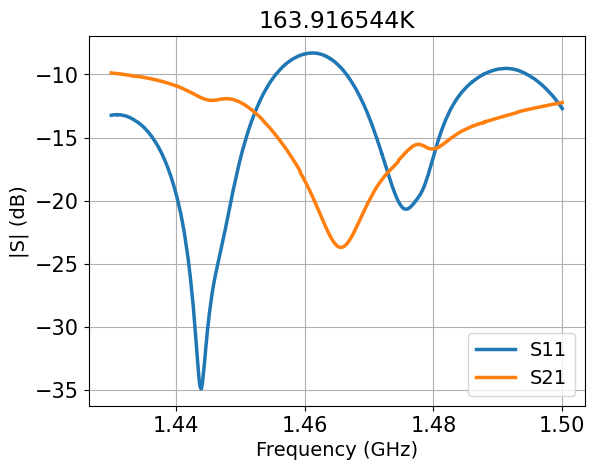

2026-05-27 23:19:01,453 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:19:01,841 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:19:01,842 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:19:01,844 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:19:01,845 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:19:02,513 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:19:02,515 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:19:02,516 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:19:02,518 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

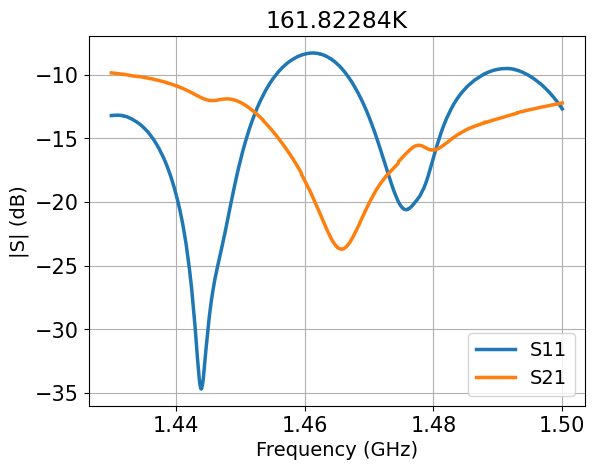

2026-05-27 23:24:10,654 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:24:11,041 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:24:11,042 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:24:11,044 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:24:11,045 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:24:11,713 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:24:11,715 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:24:11,716 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:24:11,718 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

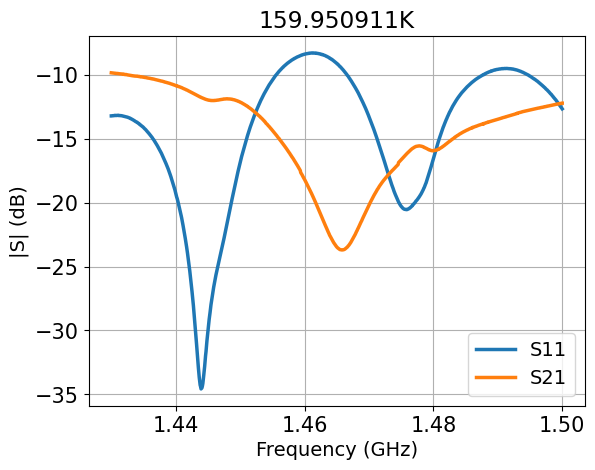

2026-05-27 23:29:54,238 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:29:54,626 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:29:54,627 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:29:54,629 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:29:54,631 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:29:55,298 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:29:55,300 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:29:55,301 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:29:55,302 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

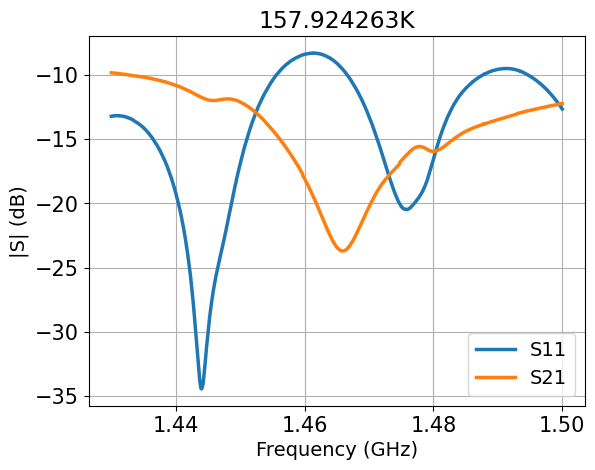

2026-05-27 23:35:37,626 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:35:38,014 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:35:38,015 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:35:38,016 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:35:38,018 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:35:38,686 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:35:38,687 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:35:38,689 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:35:38,690 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

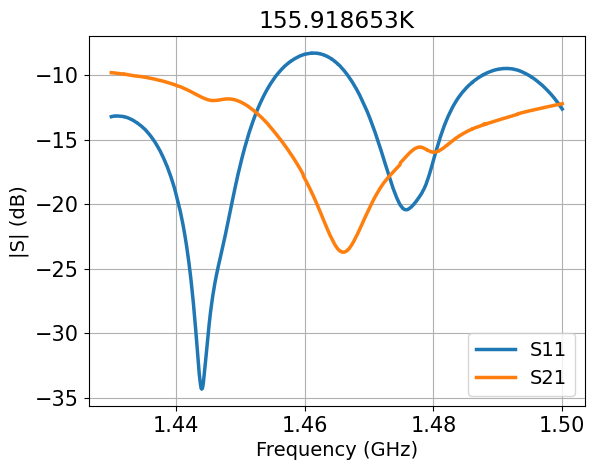

2026-05-27 23:41:21,430 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:41:21,818 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:41:21,819 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:41:21,820 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:41:21,822 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:41:22,490 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:41:22,492 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:41:22,493 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:41:22,495 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

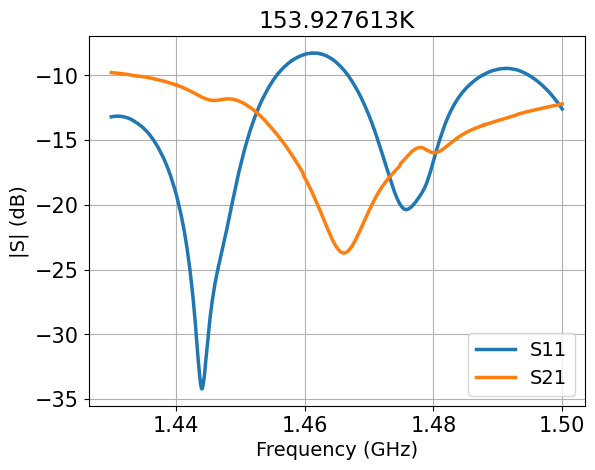

2026-05-27 23:47:05,020 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:47:05,407 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:47:05,408 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:47:05,409 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:47:05,409 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:47:06,076 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:47:06,078 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:47:06,079 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:47:06,081 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

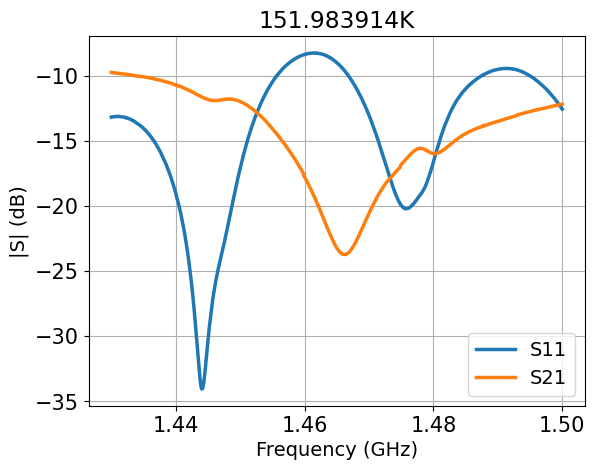

2026-05-27 23:53:22,600 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:53:22,988 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:53:22,990 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:53:22,992 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:53:22,993 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:53:23,661 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:53:23,662 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:53:23,663 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:53:23,665 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

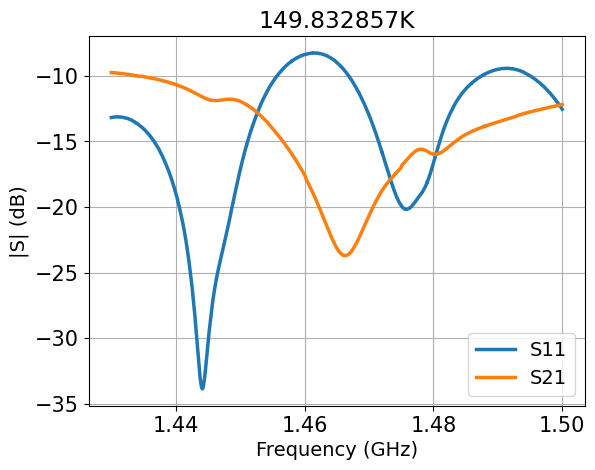

2026-05-27 23:59:06,202 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-27 23:59:06,591 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:59:06,592 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:59:06,593 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:59:06,594 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-27 23:59:07,261 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-27 23:59:07,263 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:59:07,264 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-27 23:59:07,266 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

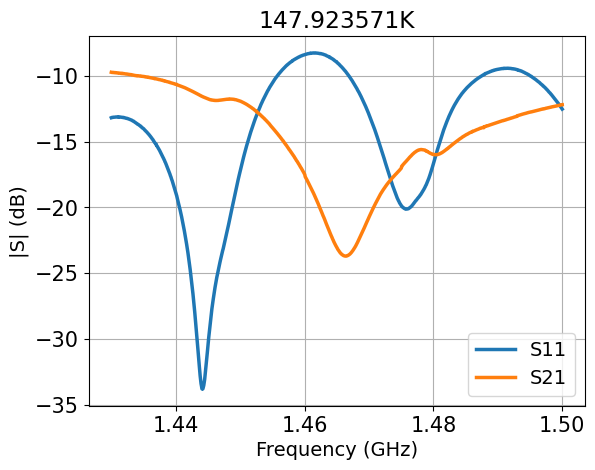

2026-05-28 00:05:24,189 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:05:24,577 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:05:24,579 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:05:24,580 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:05:24,582 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:05:25,250 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:05:25,252 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:05:25,253 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:05:25,254 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

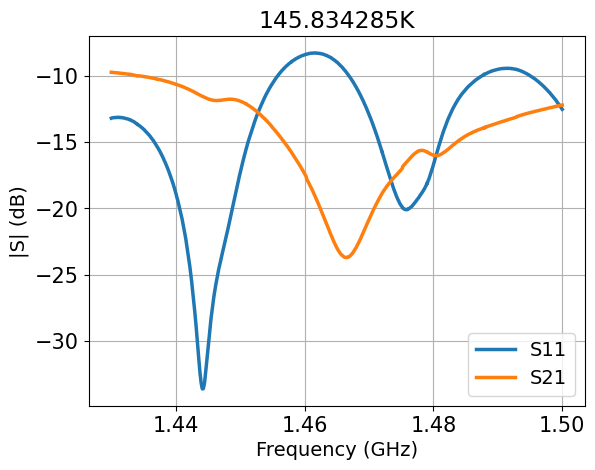

2026-05-28 00:11:07,789 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:11:08,177 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:11:08,179 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:11:08,180 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:11:08,181 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:11:08,849 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:11:08,851 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:11:08,852 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:11:08,853 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

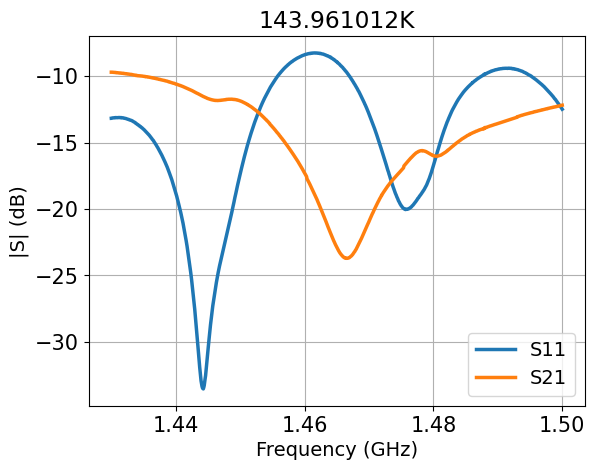

2026-05-28 00:17:25,399 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:17:25,787 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:17:25,788 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:17:25,790 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:17:25,791 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:17:26,459 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:17:26,460 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:17:26,461 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:17:26,463 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

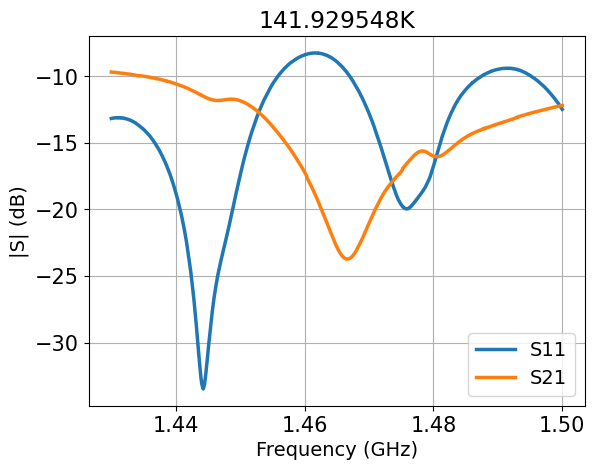

2026-05-28 00:23:43,194 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:23:43,582 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:23:43,584 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:23:43,585 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:23:43,586 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:23:44,254 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:23:44,256 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:23:44,257 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:23:44,259 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

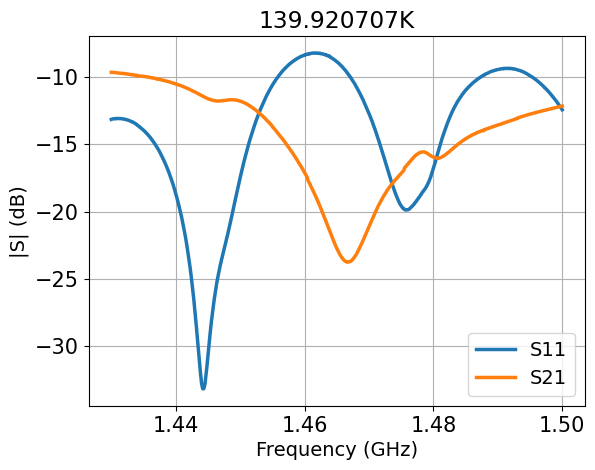

2026-05-28 00:30:01,372 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:30:01,760 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:30:01,762 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:30:01,763 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:30:01,764 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:30:02,433 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:30:02,434 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:30:02,435 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:30:02,438 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

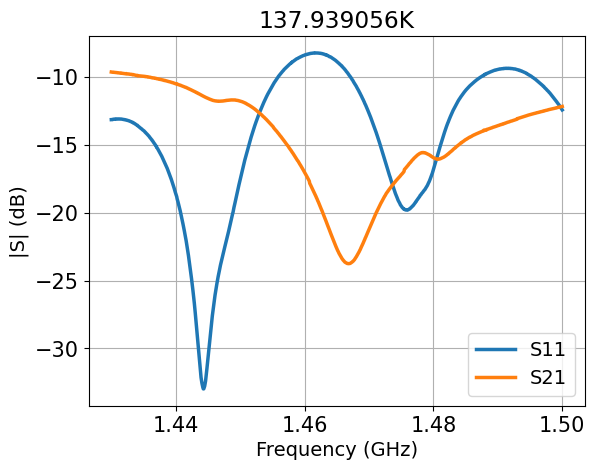

2026-05-28 00:36:19,369 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:36:19,755 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:36:19,756 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:36:19,756 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:36:19,757 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:36:20,424 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:36:20,426 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:36:20,427 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:36:20,429 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

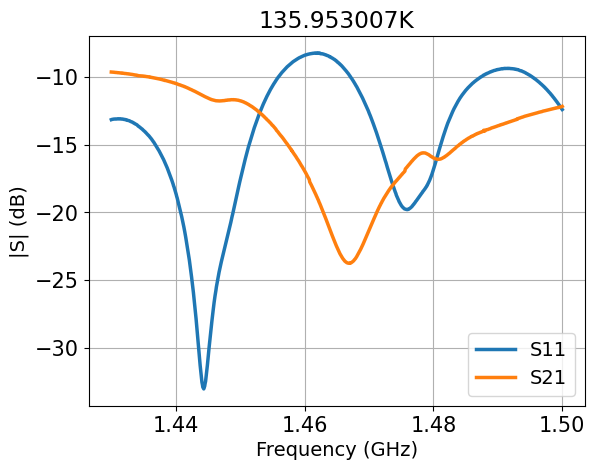

2026-05-28 00:43:11,368 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:43:11,756 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:43:11,757 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:43:11,759 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:43:11,760 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:43:12,428 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:43:12,429 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:43:12,431 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:43:12,433 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

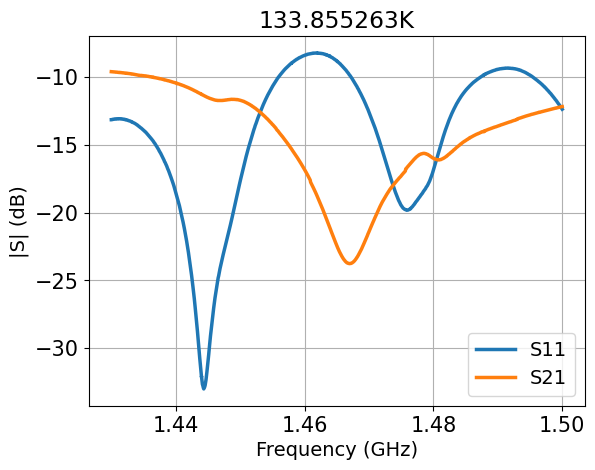

2026-05-28 00:49:29,549 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:49:29,937 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:49:29,938 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:49:29,939 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:49:29,940 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:49:30,608 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:49:30,609 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:49:30,611 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:49:30,613 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

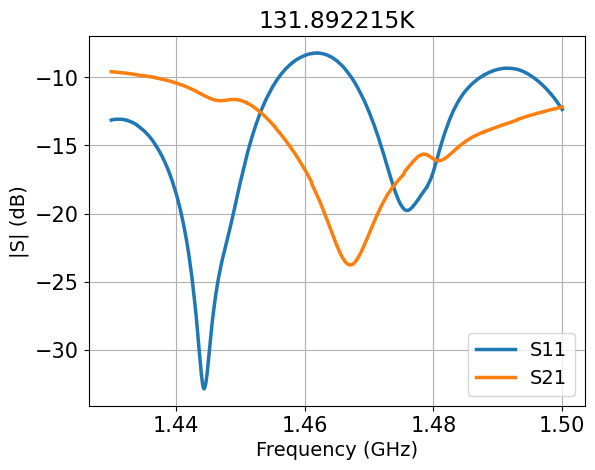

2026-05-28 00:56:21,936 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 00:56:22,322 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:56:22,324 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:56:22,325 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:56:22,326 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 00:56:22,995 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 00:56:22,996 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:56:22,997 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 00:56:22,999 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

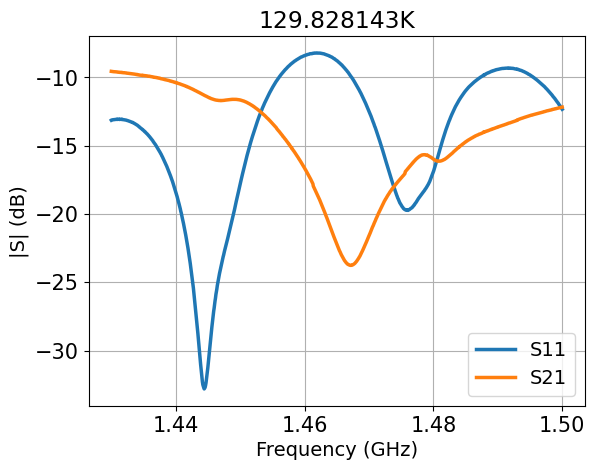

2026-05-28 01:02:39,522 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:02:39,909 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:02:39,911 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:02:39,912 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:02:39,914 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:02:40,582 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:02:40,583 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:02:40,585 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:02:40,586 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

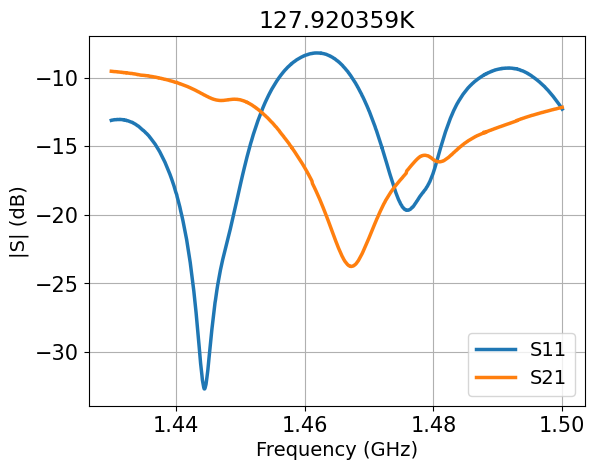

2026-05-28 01:09:31,534 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:09:31,923 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:09:31,925 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:09:31,926 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:09:31,927 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:09:32,594 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:09:32,595 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:09:32,596 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:09:32,598 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

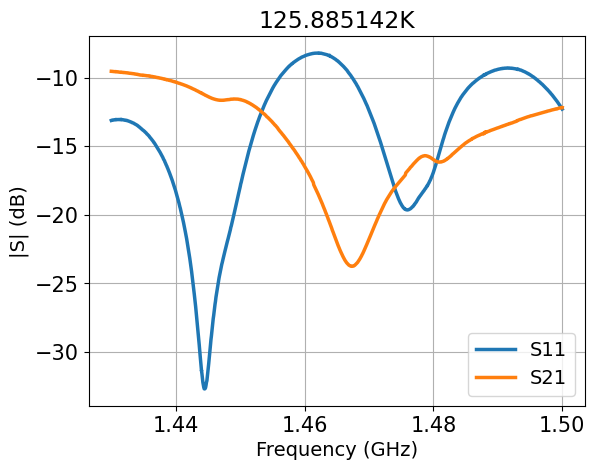

2026-05-28 01:16:24,115 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:16:24,503 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:16:24,505 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:16:24,506 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:16:24,507 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:16:25,175 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:16:25,177 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:16:25,178 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:16:25,179 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

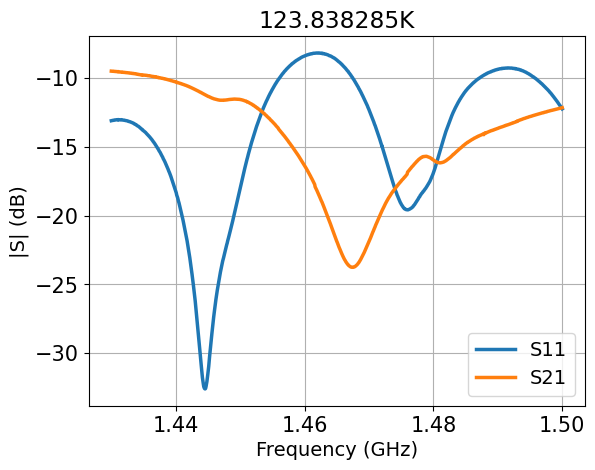

2026-05-28 01:22:42,123 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:22:42,511 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:22:42,512 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:22:42,513 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:22:42,515 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:22:43,182 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:22:43,184 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:22:43,185 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:22:43,187 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

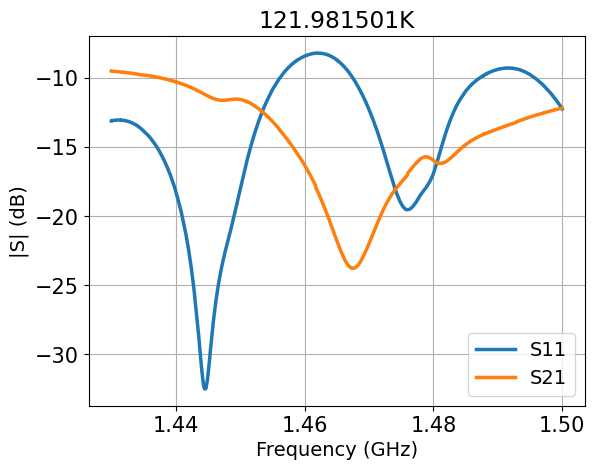

2026-05-28 01:29:34,302 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:29:34,690 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:29:34,692 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:29:34,694 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:29:34,695 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:29:35,363 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:29:35,364 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:29:35,365 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:29:35,367 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

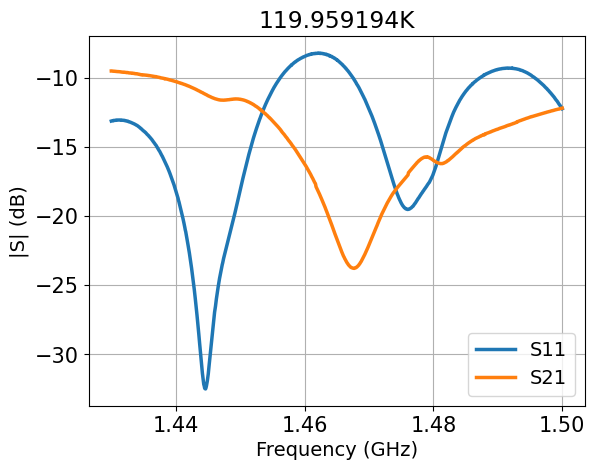

2026-05-28 01:36:26,495 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:36:26,883 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:36:26,884 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:36:26,885 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:36:26,887 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:36:27,555 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:36:27,557 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:36:27,558 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:36:27,559 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

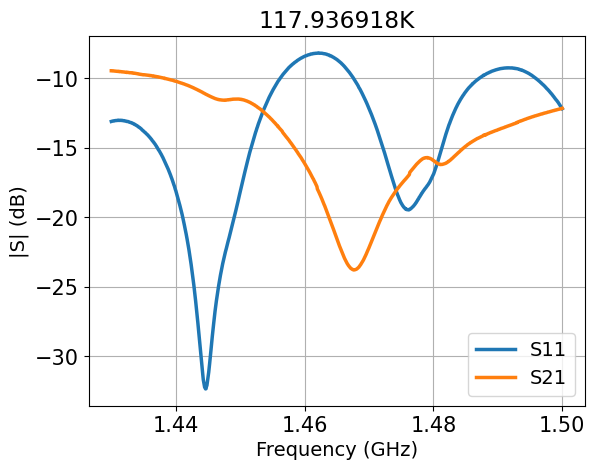

2026-05-28 01:43:18,699 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000
2026-05-28 01:43:19,087 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:43:19,089 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:43:19,090 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:43:19,091 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1437000000 step 70000
2026-05-28 01:43:19,759 - root - CRITICAL - No calibration has been applied, it is strongly recommended to calibrate you NanoVNA.
2026-05-28 01:43:19,761 - root - CRITICAL - 1 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:43:19,762 - root - CRITICAL - 2 port calibration not valid, it is recommended to re-calibrate.
2026-05-28 01:43:19,763 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: 

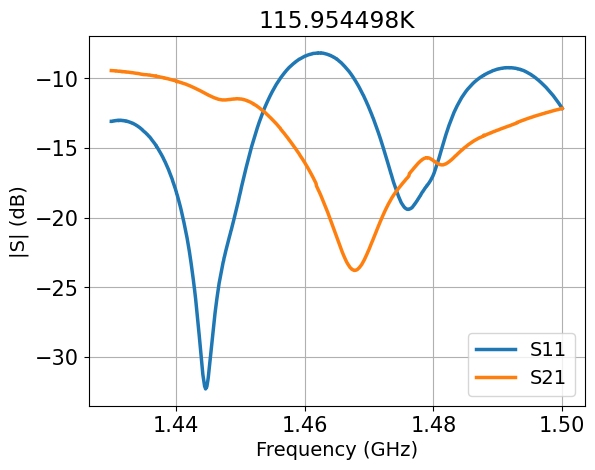

2026-05-28 01:50:10,485 - pynanovna.hardware.NanoVNA_V2 - INFO - NanoVNAV2: set sweep start 1430000000 step 70000


>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sleep for 1s and continuing
>>> Serial exception caught, sl

In [ ]:
folder_path = base #+ r'warmup_02192026_trap'
os.makedirs(folder_path, exist_ok=True)
temp_list = list(range(290,4,-2))
query_period = 15 # s 
timeout_0 = 100 # N x query period

timeout = timeout_0
curr_T_i = 0 
while curr_T_i < len(temp_list) and timeout > 0: 
    curr_T = query_temp("0.4K") 
    if curr_T <= temp_list[curr_T_i]: 
        filename = f'{curr_T}.csv'
        try:
            S11_0, S21_0, freq = take_vna_sweep(filename, folder_path, 1.43e9, 1.50e9, vna, N_points=1000)
            plot(freq/1e9, 20*np.log10(abs(S11_0)), label='S11', xlabel='Frequency (GHz)', ylabel='|S| (dB)')
            plot(freq/1e9, 20*np.log10(abs(S21_0)), label='S21', xlabel='Frequency (GHz)', ylabel='|S| (dB)', title=f'{curr_T}K')
            plt.legend() 
            plt.show()
            curr_T_i += 1 
            timeout = timeout_0
        except: 
            print(">>> Serial exception caught, sleep for 1s and continuing")
            time.sleep(1)
    else: 
        time.sleep(query_period) 
        timeout -= 1
        if timeout == 0: 
            print(f">>> Temperature cannot reach the desired {temp_list[curr_T_i]}K limit in {timeout_0} queries, current temperature {curr_T:.2f}K")